# Dataset Loading

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import os

path = '/content/drive/MyDrive/med_dataset'

try:
    patients_df = pd.read_csv(os.path.join(path, 'patients.csv'))
    diagnoses_df = pd.read_csv(os.path.join(path, 'diagnoses.csv'))
    outcomes_df = pd.read_csv(os.path.join(path, 'outcomes.csv'))
    lab_results_df = pd.read_csv(os.path.join(path, 'lab_results.csv'))
    medications_df = pd.read_csv(os.path.join(path, 'medications.csv'))
    print("All datasets loaded successfully!")
    print("DataFrames created: patients_df, diagnoses_df, outcomes_df, lab_results_df, medications_df")
except Exception as e:
    print(f"error occurred: {e}")

All datasets loaded successfully!
DataFrames created: patients_df, diagnoses_df, outcomes_df, lab_results_df, medications_df


# SECTION 1 - SETUP

In [ ]:
# ANSI helpers
RESET  = "\033[0m"
BOLD   = "\033[1m"
CYAN   = "\033[96m"
GREEN  = "\033[92m"
RED    = "\033[91m"
YELLOW = "\033[93m"
DIM    = "\033[2m"

bar  = "═" * 60
thin = "─" * 60

def c(text, *styles):
    return "".join(styles) + str(text) + RESET

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.width", 120)

# Global plot style
sns.set_theme(style="whitegrid", font_scale=1.15)
PALETTE   = "Set2"
FIG_DPI   = 150
TITLE_PAD = 14

# Verify DataFrames exist & print shapes
EXPECTED = {
    "patients_df":   ["patient_id","age","sex","bmi","systolic_bp","diastolic_bp",
                       "heart_rate","temperature_f","smoking_status","alcohol_use",
                       "exercise_level","insurance_type","charlson_index"],
    "diagnoses_df":  ["patient_id","visit_date","visit_type","primary_diagnosis",
                       "primary_icd10","secondary_diagnoses","secondary_icd10s",
                       "provider_specialty"],
    "outcomes_df":   ["patient_id","admission_date","discharge_date",
                       "length_of_stay_days","icu_admission","icu_days",
                       "in_hospital_death","discharge_disposition","readmitted_30d",
                       "days_to_readmission","primary_drg","total_charges_usd"],
    "lab_results_df":["patient_id","test_date","test_name","value","unit",
                       "reference_low","reference_high","flag","is_abnormal",
                       "delta_from_normal"],
    "medications_df":["patient_id","medication","dose","unit","frequency",
                       "indication","start_date","duration_days","is_generic",
                       "adherence_pct"],
}

print("=" * 60)
print("  DATAFRAMES")
print("=" * 60)
for name in EXPECTED:
    try:
        df = eval(name)
        status = "✅"
        shape  = df.shape
    except NameError:
        status = "NOT FOUND"
        shape  = ("—", "—")
    print(f"  {status}  {name:<20}  rows={shape[0]:>7,}  cols={shape[1]}")
print("=" * 60)

  DATAFRAMES
  ✅  patients_df           rows=100,000  cols=28
  ✅  diagnoses_df          rows=274,592  cols=8
  ✅  outcomes_df           rows= 11,001  cols=12
  ✅  lab_results_df        rows=2,827,722  cols=10
  ✅  medications_df        rows=364,174  cols=10


# SECTION 2 - ETL

In [ ]:
def etl_report(df: pd.DataFrame, name: str) -> None:
    """Print a structured ETL report for a single DataFrame."""

    print(f"\n{c(bar, CYAN)}")
    print(f"  {c(name, BOLD, CYAN)}")
    print(f"{c(bar, CYAN)}")

    print(f"\n  {c('Shape', BOLD)} : {df.shape[0]:,} rows × {df.shape[1]} columns")

    print(f"\n  {c('Columns', BOLD)} ({df.shape[1]}):")
    for i, col in enumerate(df.columns, 1):
        print(f"    {c(f'{i:>2}.', DIM)} {col}")

    print(f"\n  {c('Data Types:', BOLD)}")
    for dtype, cnt in df.dtypes.value_counts().items():
        print(f"    {c(str(dtype)+':', YELLOW):<24} {cnt} column(s)")

    print(f"\n  {c(thin, DIM)}")

    null_counts  = df.isnull().sum()
    null_summary = pd.DataFrame({
        "missing_count": null_counts,
        "missing_pct":   (null_counts / len(df) * 100).round(2),
    })
    null_summary = null_summary[null_summary["missing_count"] > 0]

    if null_summary.empty:
        print(f"  {c('✓ No missing values detected.', GREEN)}")
    else:
        print(f"  {c(f'✗ Missing Values ({len(null_summary)} columns affected):', RED)}")
        print(null_summary.to_string())

    dupe_count = df.duplicated().sum()
    if dupe_count == 0:
        print(f"  {c('✓ No duplicate rows detected.', GREEN)}")
    else:
        print(f"  {c(f'✗ Duplicate Rows: {dupe_count:,}', RED)}")

    num_df = df.select_dtypes(include="number")
    if not num_df.empty:
        print(f"\n  {c(thin, DIM)}")
        print(f"  {c('Descriptive Statistics (numeric):', BOLD)}")
        print(num_df.describe().T.to_string())


for df_name in EXPECTED:
    try:
        etl_report(eval(df_name), df_name)
    except NameError:
        print(f"  {c(f'{df_name} not available — skipping.', DIM)}")


for df_name, date_cols in [
    ("outcomes_df",    ["admission_date", "discharge_date"]),
    ("diagnoses_df",   ["visit_date"]),
    ("medications_df", ["start_date"]),
    ("lab_results_df", ["test_date"]),
]:
    try:
        df = eval(df_name)
        for col in date_cols:
            if col in df.columns:
                df[col] = pd.to_datetime(df[col], errors="coerce")
    except NameError:
        pass

print(c("✓ Date columns parsed for outcomes_df, diagnoses_df, medications_df, lab_results_df", GREEN, BOLD))


════════════════════════════════════════════════════════════
  patients_df
════════════════════════════════════════════════════════════

  Shape : 100,000 rows × 28 columns

  Columns (28):
     1. patient_id
     2. age
     3. sex
     4. bmi
     5. systolic_bp
     6. diastolic_bp
     7. heart_rate
     8. temperature_f
     9. smoking_status
    10. alcohol_use
    11. exercise_level
    12. insurance_type
    13. charlson_index
    14. dx_hypertension
    15. dx_type2_diabetes
    16. dx_hyperlipidemia
    17. dx_obesity
    18. dx_coronary_artery_disease
    19. dx_heart_failure
    20. dx_atrial_fibrillation
    21. dx_chronic_kidney_disease
    22. dx_copd
    23. dx_asthma
    24. dx_depression
    25. dx_anxiety
    26. dx_hypothyroidism
    27. dx_osteoarthritis
    28. dx_type1_diabetes

  Data Types:
    int64:          20 column(s)
    object:         6 column(s)
    float64:        2 column(s)

  ────────────────────────────────────────────────────────────
  ✓ No miss

# SECTION 3 — EDA

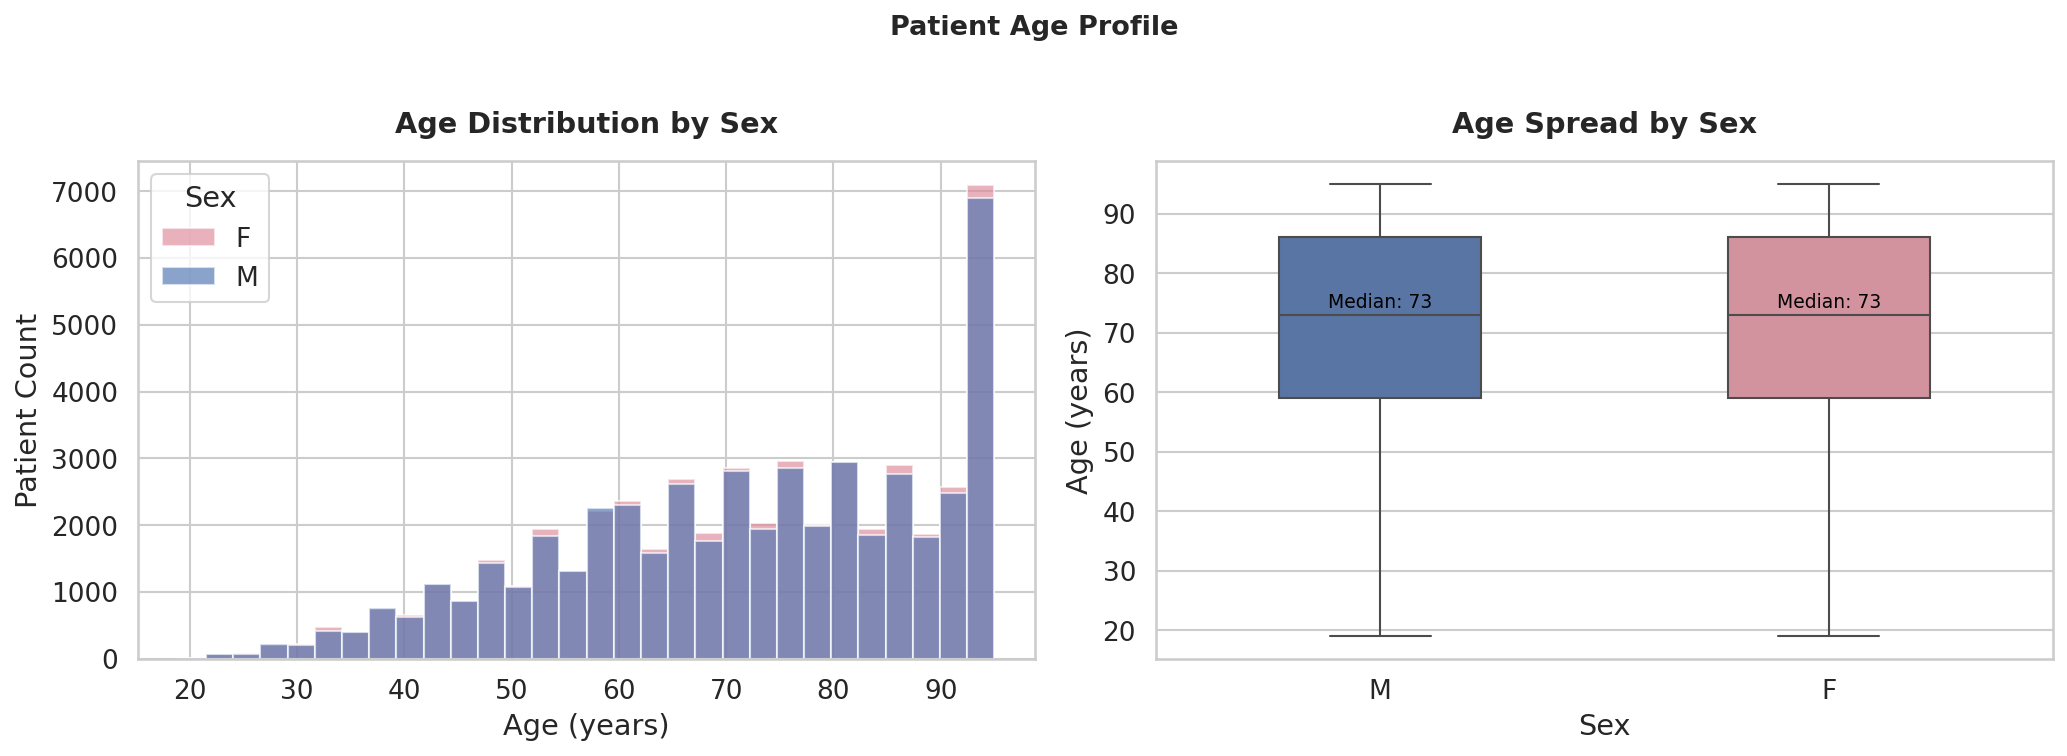

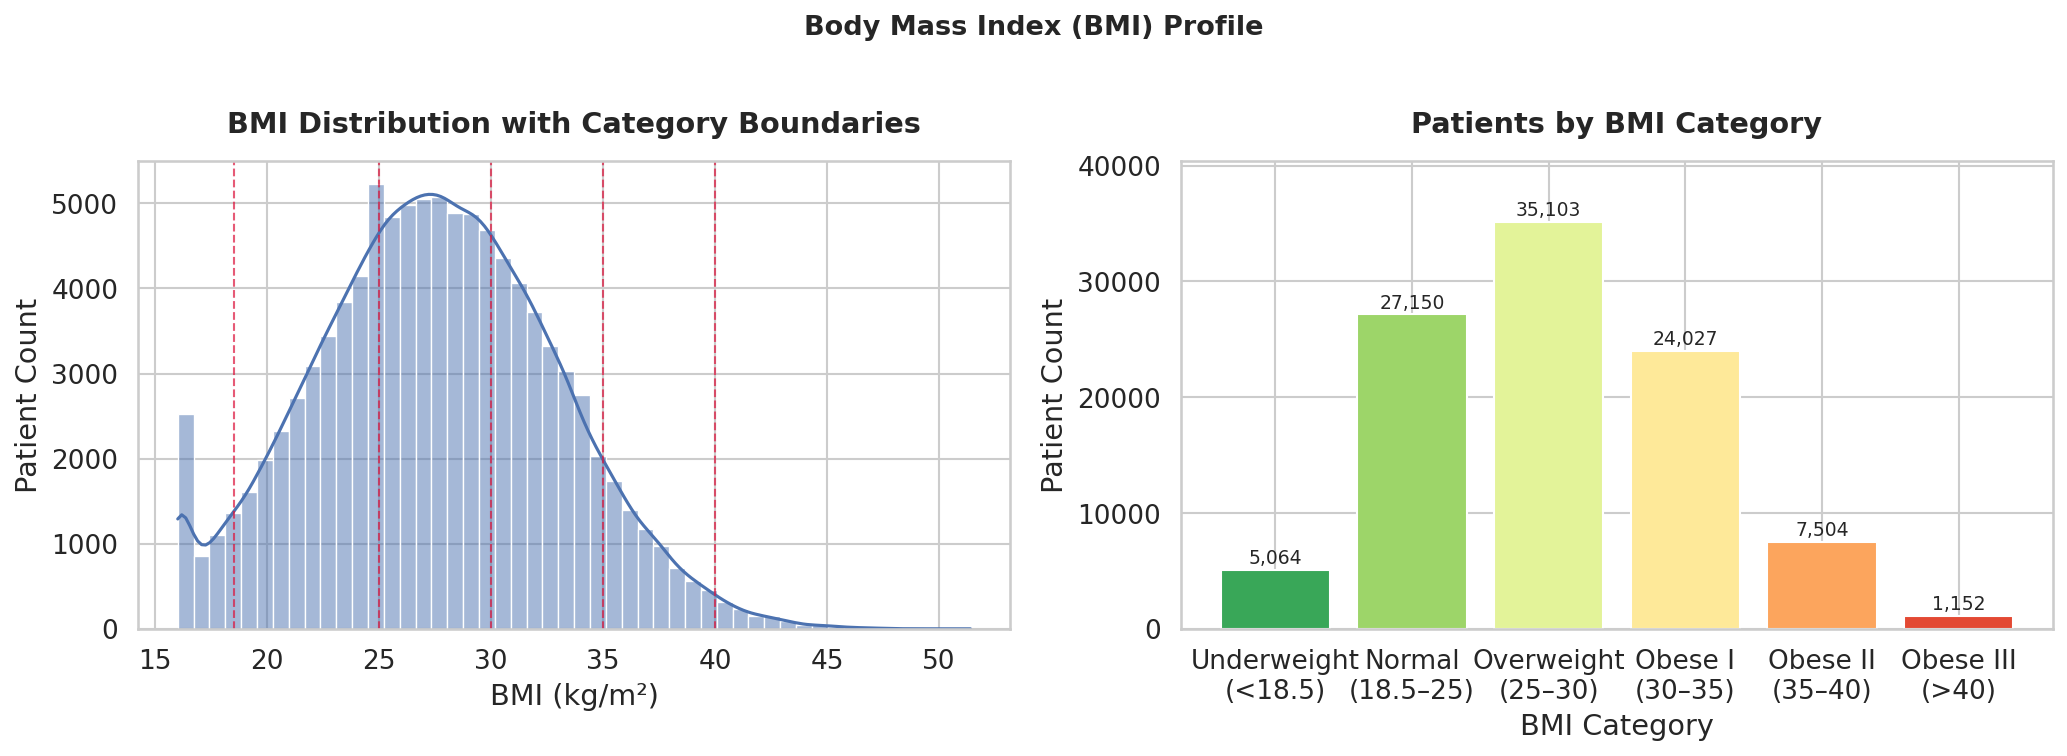

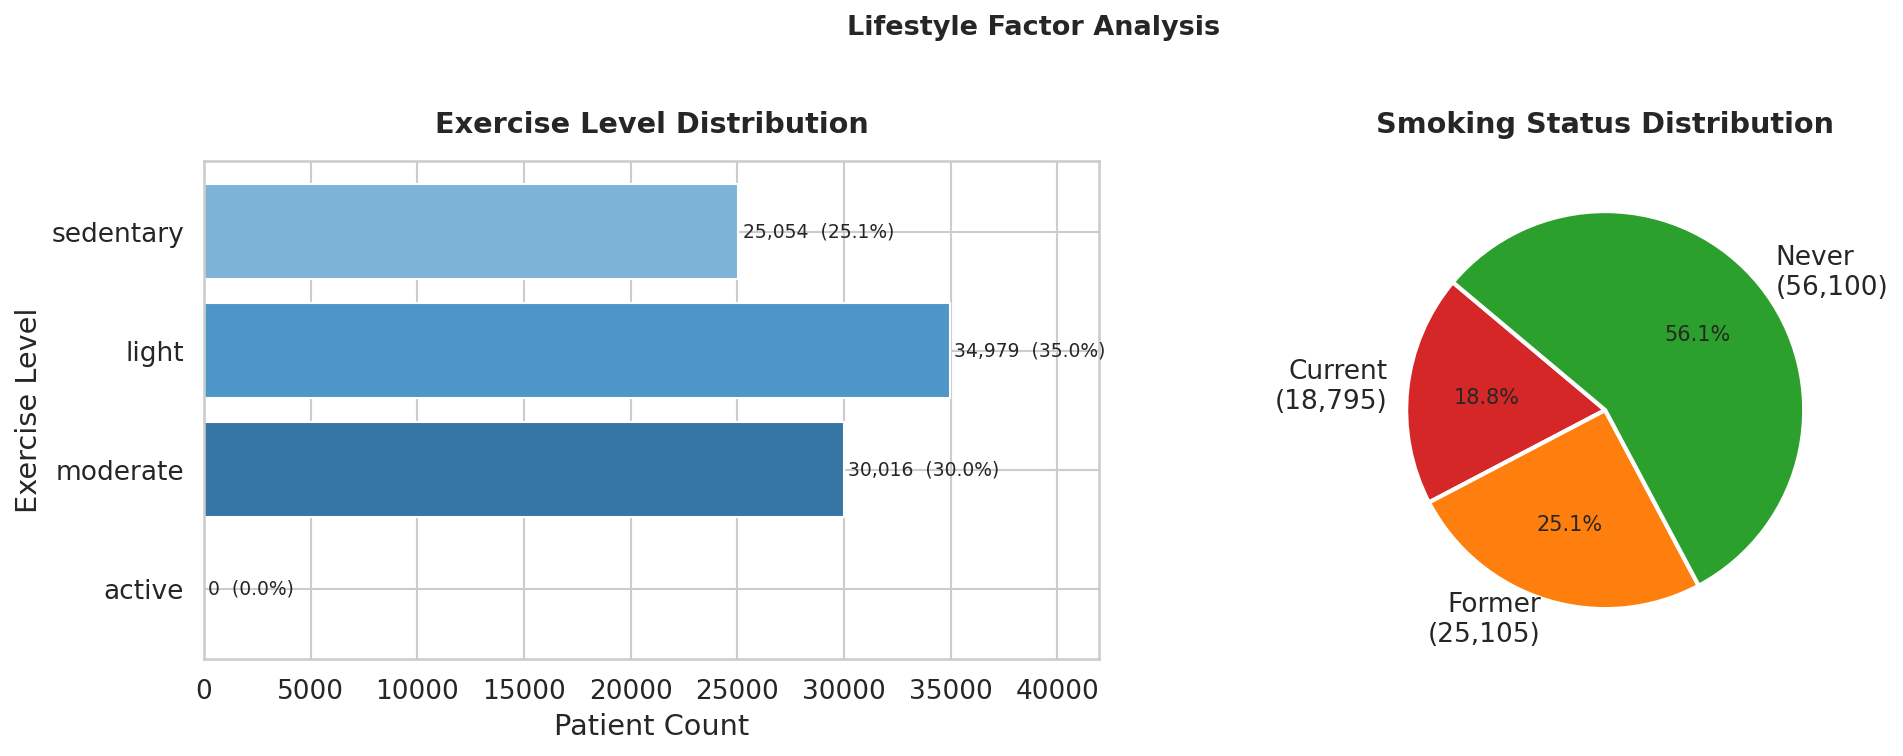

In [ ]:
# 3.1  Age Distribution by Sex
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=FIG_DPI)

sex_palette = {"M": "#4C72B0", "F": "#D89"}

# Histogram
for sex, grp in patients_df.groupby("sex"):
    axes[0].hist(grp["age"], bins=30, alpha=0.65,
                 color=sex_palette.get(sex, "grey"), label=sex, edgecolor="white")
axes[0].set_title("Age Distribution by Sex", fontweight="bold", pad=TITLE_PAD)
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Patient Count")
axes[0].legend(title="Sex")
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(10))

# Boxplot
sns.boxplot(data=patients_df, x="sex", y="age",
            palette=sex_palette, width=0.45, ax=axes[1])
axes[1].set_title("Age Spread by Sex", fontweight="bold", pad=TITLE_PAD)
axes[1].set_xlabel("Sex")
axes[1].set_ylabel("Age (years)")

for i, sex in enumerate(patients_df["sex"].unique()):
    median = patients_df.loc[patients_df["sex"] == sex, "age"].median()
    axes[1].text(i, median + 1.2, f"Median: {median:.0f}",
                 ha="center", fontsize=9, color="black")

plt.suptitle("Patient Age Profile", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("eda_age_distribution.png", bbox_inches="tight", dpi=FIG_DPI)
plt.show()


# 3.2  Insurance Type Distribution
ins_counts = patients_df["insurance_type"].value_counts()

fig = px.pie(
    values=ins_counts.values,
    names=ins_counts.index,
    title="Insurance Type Distribution",
    color_discrete_sequence=px.colors.qualitative.Set2,
    hole=0.35,
)
fig.update_traces(textposition="outside", textinfo="percent+label",
                  pull=[0.04] * len(ins_counts))
fig.update_layout(title_font_size=16, legend_title="Insurance Type",
                  margin=dict(t=60, b=40, l=20, r=20))
fig.show()

# 3.3  BMI Distribution
bmi_bins   = [0, 18.5, 25, 30, 35, 40, np.inf]
bmi_labels = ["Underweight\n(<18.5)", "Normal\n(18.5–25)",
              "Overweight\n(25–30)", "Obese I\n(30–35)",
              "Obese II\n(35–40)", "Obese III\n(>40)"]
patients_df["bmi_category"] = pd.cut(patients_df["bmi"],
                                      bins=bmi_bins, labels=bmi_labels, right=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=FIG_DPI)

# Histogram + kde
sns.histplot(patients_df["bmi"], bins=50, kde=True,
             color="#4C72B0", edgecolor="white", ax=axes[0])
for x in bmi_bins[1:-1]:
    axes[0].axvline(x, color="crimson", linestyle="--", linewidth=1, alpha=0.7)
axes[0].set_title("BMI Distribution with Category Boundaries", fontweight="bold", pad=TITLE_PAD)
axes[0].set_xlabel("BMI (kg/m²)")
axes[0].set_ylabel("Patient Count")

# Barchart
cat_counts = patients_df["bmi_category"].value_counts().reindex(bmi_labels)
bars = axes[1].bar(bmi_labels, cat_counts.values,
                   color=sns.color_palette("RdYlGn_r", len(bmi_labels)),
                   edgecolor="white")
for bar, val in zip(bars, cat_counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 200, f"{val:,}",
                 ha="center", va="bottom", fontsize=9)
axes[1].set_title("Patients by BMI Category", fontweight="bold", pad=TITLE_PAD)
axes[1].set_xlabel("BMI Category")
axes[1].set_ylabel("Patient Count")
axes[1].set_ylim(0, cat_counts.max() * 1.15)

plt.suptitle("Body Mass Index (BMI) Profile", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("eda_bmi_distribution.png", bbox_inches="tight", dpi=FIG_DPI)
plt.show()

# 3.4  Lifestyle Factor
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=FIG_DPI)

# Exercise level
ex_order    = ["sedentary", "light", "moderate", "active"]
ex_counts   = patients_df["exercise_level"].str.lower().value_counts().reindex(ex_order).fillna(0)
ex_palette  = sns.color_palette("Blues_d", len(ex_order))
ex_reversed = ex_counts.reindex(ex_order[::-1])

bars = axes[0].barh(ex_order[::-1], ex_reversed.values,
                    color=ex_palette[::-1], edgecolor="white")
for bar, val in zip(bars, ex_reversed.values):
    axes[0].text(bar.get_width() + 200, bar.get_y() + bar.get_height() / 2,
                 f"{int(val):,}  ({val / len(patients_df) * 100:.1f}%)",
                 va="center", fontsize=9)
axes[0].set_title("Exercise Level Distribution", fontweight="bold", pad=TITLE_PAD)
axes[0].set_xlabel("Patient Count")
axes[0].set_ylabel("Exercise Level")
axes[0].set_xlim(0, ex_counts.max() * 1.20)

# Smoking status
sm_order  = ["current", "former", "never"]
sm_counts = patients_df["smoking_status"].str.lower().value_counts().reindex(sm_order).fillna(0)
sm_colors = ["#D62728", "#FF7F0E", "#2CA02C"]

wedges, texts, autotexts = axes[1].pie(
    sm_counts.values,
    labels=[f"{l.title()}\n({v:,})" for l, v in zip(sm_order, sm_counts.values)],
    autopct="%1.1f%%",
    colors=sm_colors,
    startangle=140,
    wedgeprops=dict(edgecolor="white", linewidth=2),
)
for at in autotexts:
    at.set_fontsize(10)
axes[1].set_title("Smoking Status Distribution", fontweight="bold", pad=TITLE_PAD)

plt.suptitle("Lifestyle Factor Analysis", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("eda_lifestyle_factors.png", bbox_inches="tight", dpi=FIG_DPI)
plt.show()

# SECTION 4 — DISEASE PREVALENCE

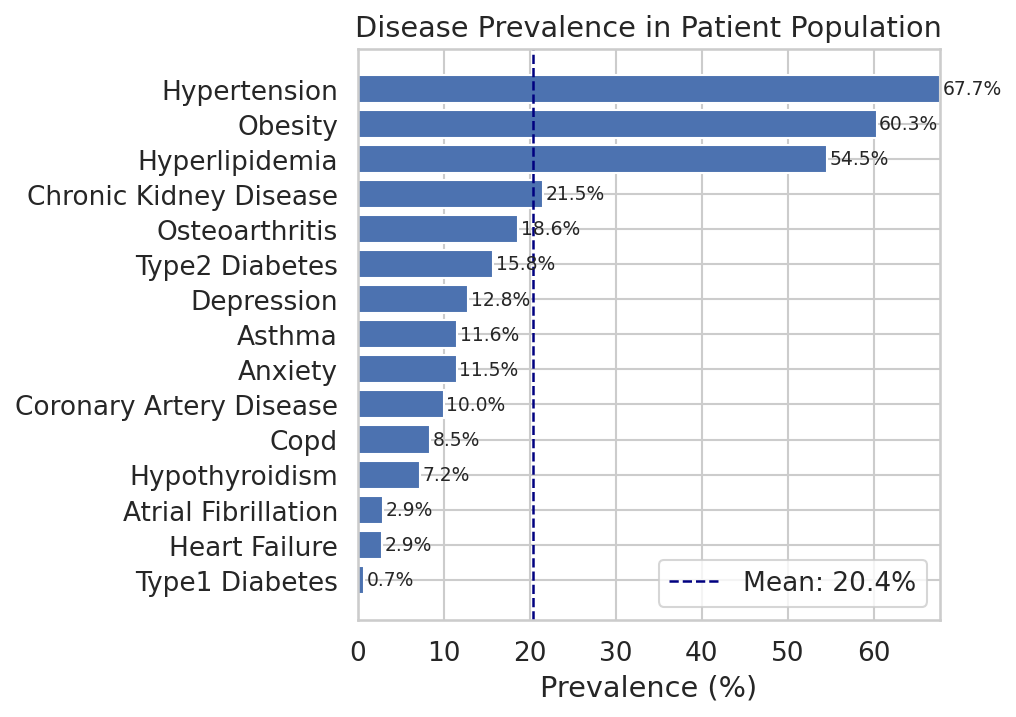

Top 5 Most Prevalent Conditions:
Hypertension             67.69
Obesity                  60.31
Hyperlipidemia           54.53
Chronic Kidney Disease   21.48
Osteoarthritis           18.63


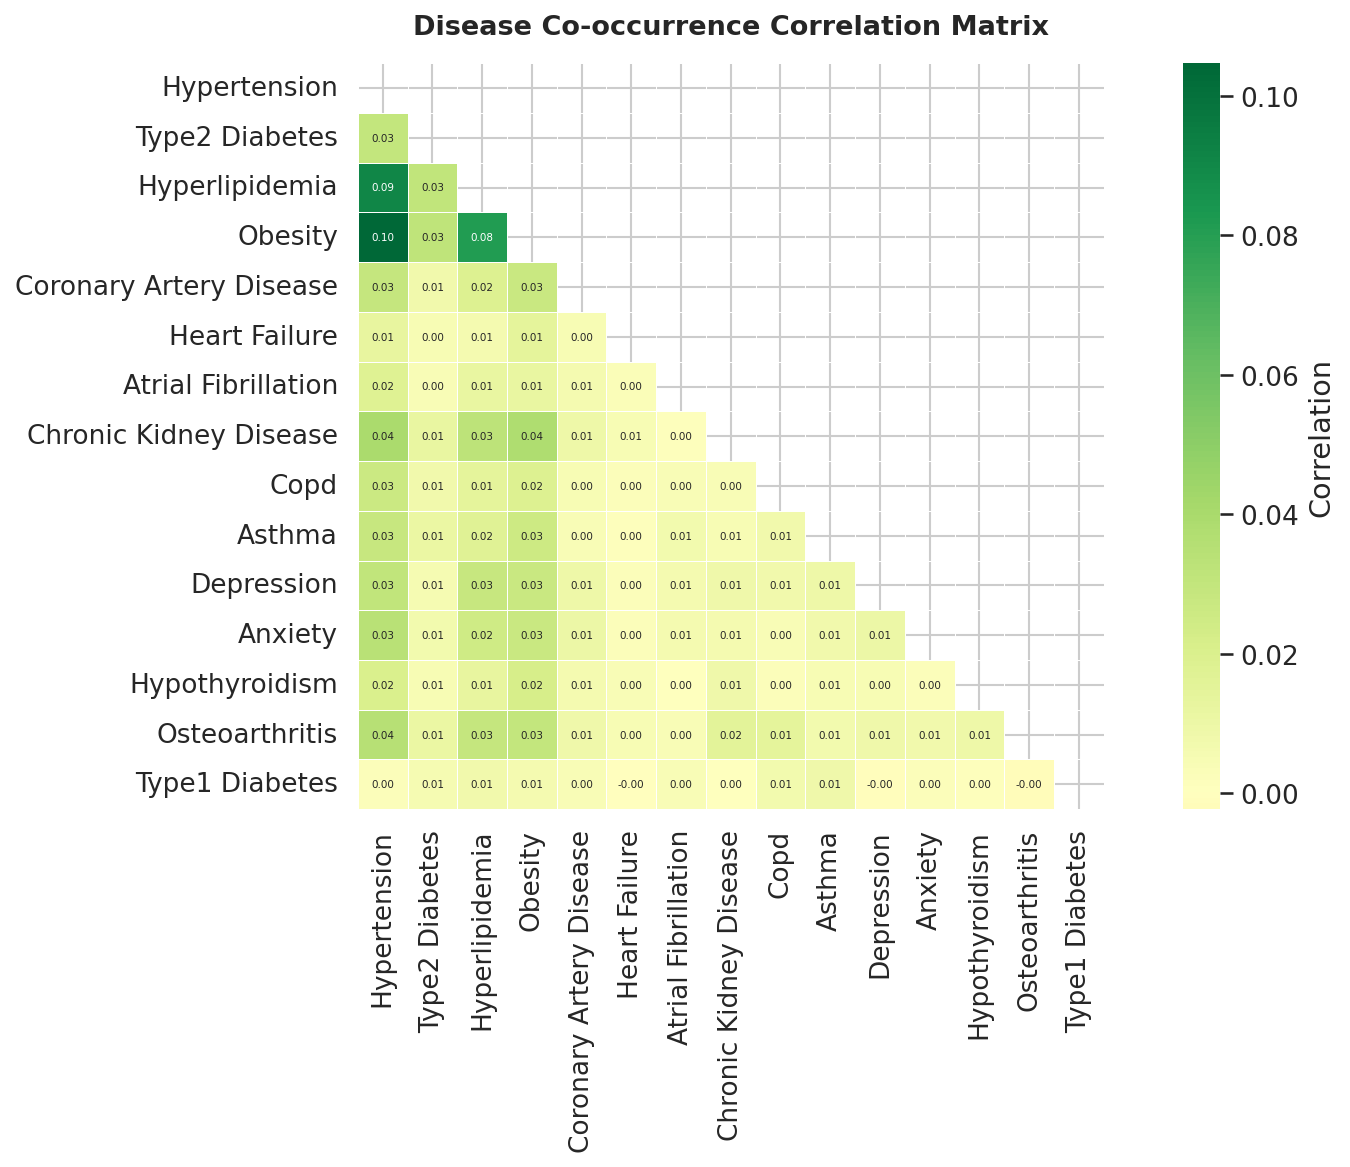

In [ ]:
DX_COLS = [c for c in patients_df.columns if c.startswith("dx_")]
DX_LABELS = {col: col.replace("dx_", "").replace("_", " ").title() for col in DX_COLS}

#4.1 Overall Disease Prevalence
prevalence = (patients_df[DX_COLS].sum()
    .div(len(patients_df))
    .mul(100)
    .rename(DX_LABELS)
    .sort_values())
fig, ax = plt.subplots(figsize=(7, 5), dpi=FIG_DPI)
bars = ax.barh(prevalence.index, prevalence.values)

for bar, val in zip(bars, prevalence.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2, f"{val:.1f}%", va="center", fontsize=9)

mean_val = prevalence.mean()

ax.set(title="Disease Prevalence in Patient Population", xlabel="Prevalence (%)", xlim=(0, prevalence.max() * 1))
ax.axvline(mean_val,color="navy", linestyle="--", linewidth=1.2, label=f"Mean: {mean_val:.1f}%")
ax.legend()
plt.tight_layout()
plt.savefig("disease_prevalence.png", bbox_inches="tight", dpi=FIG_DPI)
plt.show()
print("Top 5 Most Prevalent Conditions:")
print(prevalence.sort_values(ascending=False).head(5).to_string())

#4.2 Disease Co-occurrence Heatmap
dx_matrix = patients_df[DX_COLS].rename(columns=DX_LABELS)
corr = dx_matrix.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(12, 8), dpi=FIG_DPI)
sns.heatmap(corr, mask= mask, annot=True, fmt=".2f", cmap="RdYlGn", center=0, square=True, linewidths=.4, linecolor="white",
            annot_kws={"size": 5}, cbar_kws={"label": "Correlation"})

ax.set_title("Disease Co-occurrence Correlation Matrix", fontweight="bold", pad=TITLE_PAD, fontsize=13)
ax.tick_params(axis="x", rotation=90)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.savefig("disease_correlation_heatmap.png", bbox_inches="tight")
plt.show()

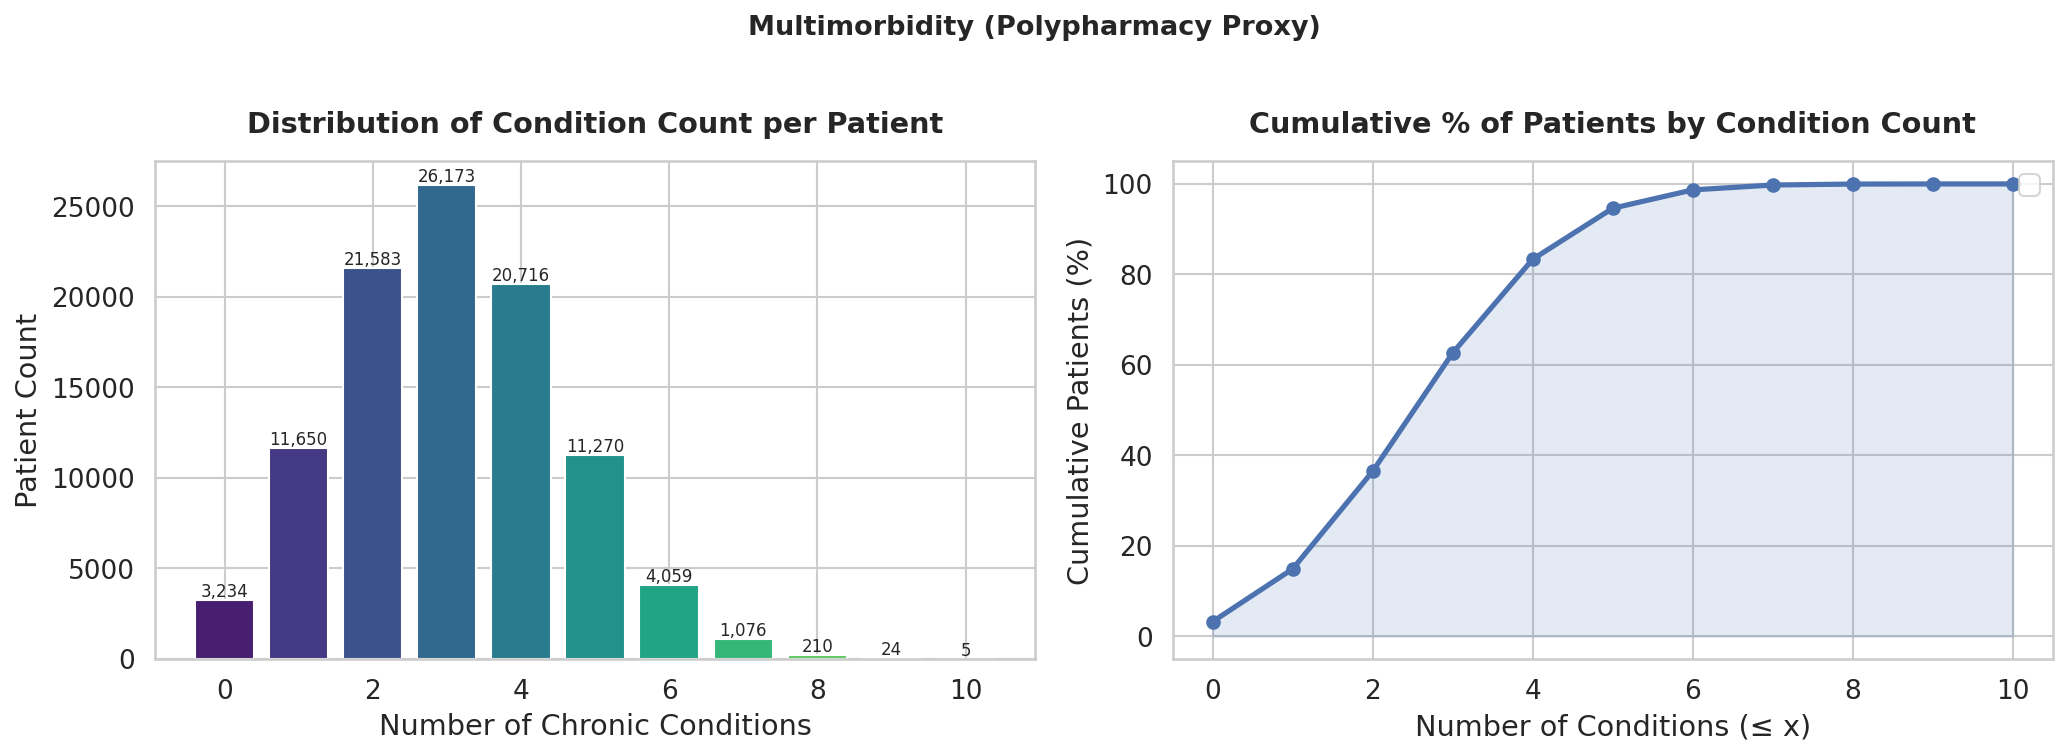


Multimorbidity Summary:
  Mean conditions per patient : 3.06
  Patients with 0 conditions  : 3,234
  Patients with 3+ conditions : 63,533
  Patients with 5+ conditions : 16,644


In [ ]:
#4.3 Prevalence by Age Group
age_bins   = [0, 30, 45, 60, 75, np.inf]
age_labels = ["<30", "30–44", "45–59", "60–74", "75+"]
patients_df["age_group"] = pd.cut(patients_df["age"], bins=age_bins, labels=age_labels, right=False)
age_prev = (patients_df.groupby("age_group", observed=True)[DX_COLS] .mean() * 100).rename(columns=DX_LABELS)

# Plotly heatmap
fig = px.imshow(age_prev.T,
    labels=dict(x="Age Group", y="Condition", color="Prevalence (%)"),
    title="Disease Prevalence by Age Group (%)", color_continuous_scale="YlOrRd", text_auto=".1f", aspect="auto")
fig.update_layout(title_font_size=15, coloraxis_colorbar=dict(title="Prevalence %"), margin=dict(t=60, b=80, l=180, r=40), height=600)
fig.show()

#4.4 Number of Conditions per Patient
patients_df["condition_count"] = patients_df[DX_COLS].sum(axis=1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=FIG_DPI)

count_dist = patients_df["condition_count"].value_counts().sort_index()
axes[0].bar(count_dist.index, count_dist.values, color=sns.color_palette("viridis", len(count_dist)))
for x, y in zip(count_dist.index, count_dist.values):
    axes[0].text(x, y + 200, f"{y:,}", ha="center", fontsize=8)

axes[0].set_title("Distribution of Condition Count per Patient", fontweight="bold", pad=TITLE_PAD)
axes[0].set_xlabel("Number of Chronic Conditions")
axes[0].set_ylabel("Patient Count")

# Cumulative %
cumulative = count_dist.cumsum() / count_dist.sum() * 100
axes[1].plot(cumulative.index, cumulative.values, marker="o", color="#4C72B0", linewidth=2.5, markersize=6)
axes[1].fill_between(cumulative.index, cumulative.values, alpha=0.15, color="#4C72B0")
axes[1].set_title("Cumulative % of Patients by Condition Count", fontweight="bold", pad=TITLE_PAD)
axes[1].set_xlabel("Number of Conditions (≤ x)")
axes[1].set_ylabel("Cumulative Patients (%)")
axes[1].legend()
plt.suptitle("Multimorbidity (Polypharmacy Proxy)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("disease_condition_count.png", bbox_inches="tight", dpi=FIG_DPI)
plt.show()

print(f"\nMultimorbidity Summary:")
print(f"  Mean conditions per patient : {patients_df['condition_count'].mean():.2f}")
print(f"  Patients with 0 conditions  : {(patients_df['condition_count'] == 0).sum():,}")
print(f"  Patients with 3+ conditions : {(patients_df['condition_count'] >= 3).sum():,}")
print(f"  Patients with 5+ conditions : {(patients_df['condition_count'] >= 5).sum():,}")

# SECTION 5 — LAB RESULT DISTRIBUTIONS

Lab Test Summary (top 15):
        test_name  n_results  mean_value  pct_abnormal
              ALT     257664       31.50          0.27
              AST     257664       24.99          0.26
       creatinine     257664        1.94         21.73
              WBC     257664        7.75          0.26
  glucose_fasting     257664      137.34         61.68
           sodium     257664      140.50          0.27
        potassium     257664        4.25          0.28
       hemoglobin     257664       14.75          0.28
              LDL     152100      136.30         93.91
total_cholesterol     152100      211.89         80.14
    triglycerides     141116      379.79        100.00
              HDL     141116       69.99          0.27
             eGFR      61080       39.67         90.79
            HbA1c      41853        8.50        100.00
              BNP      32508       50.00          0.12


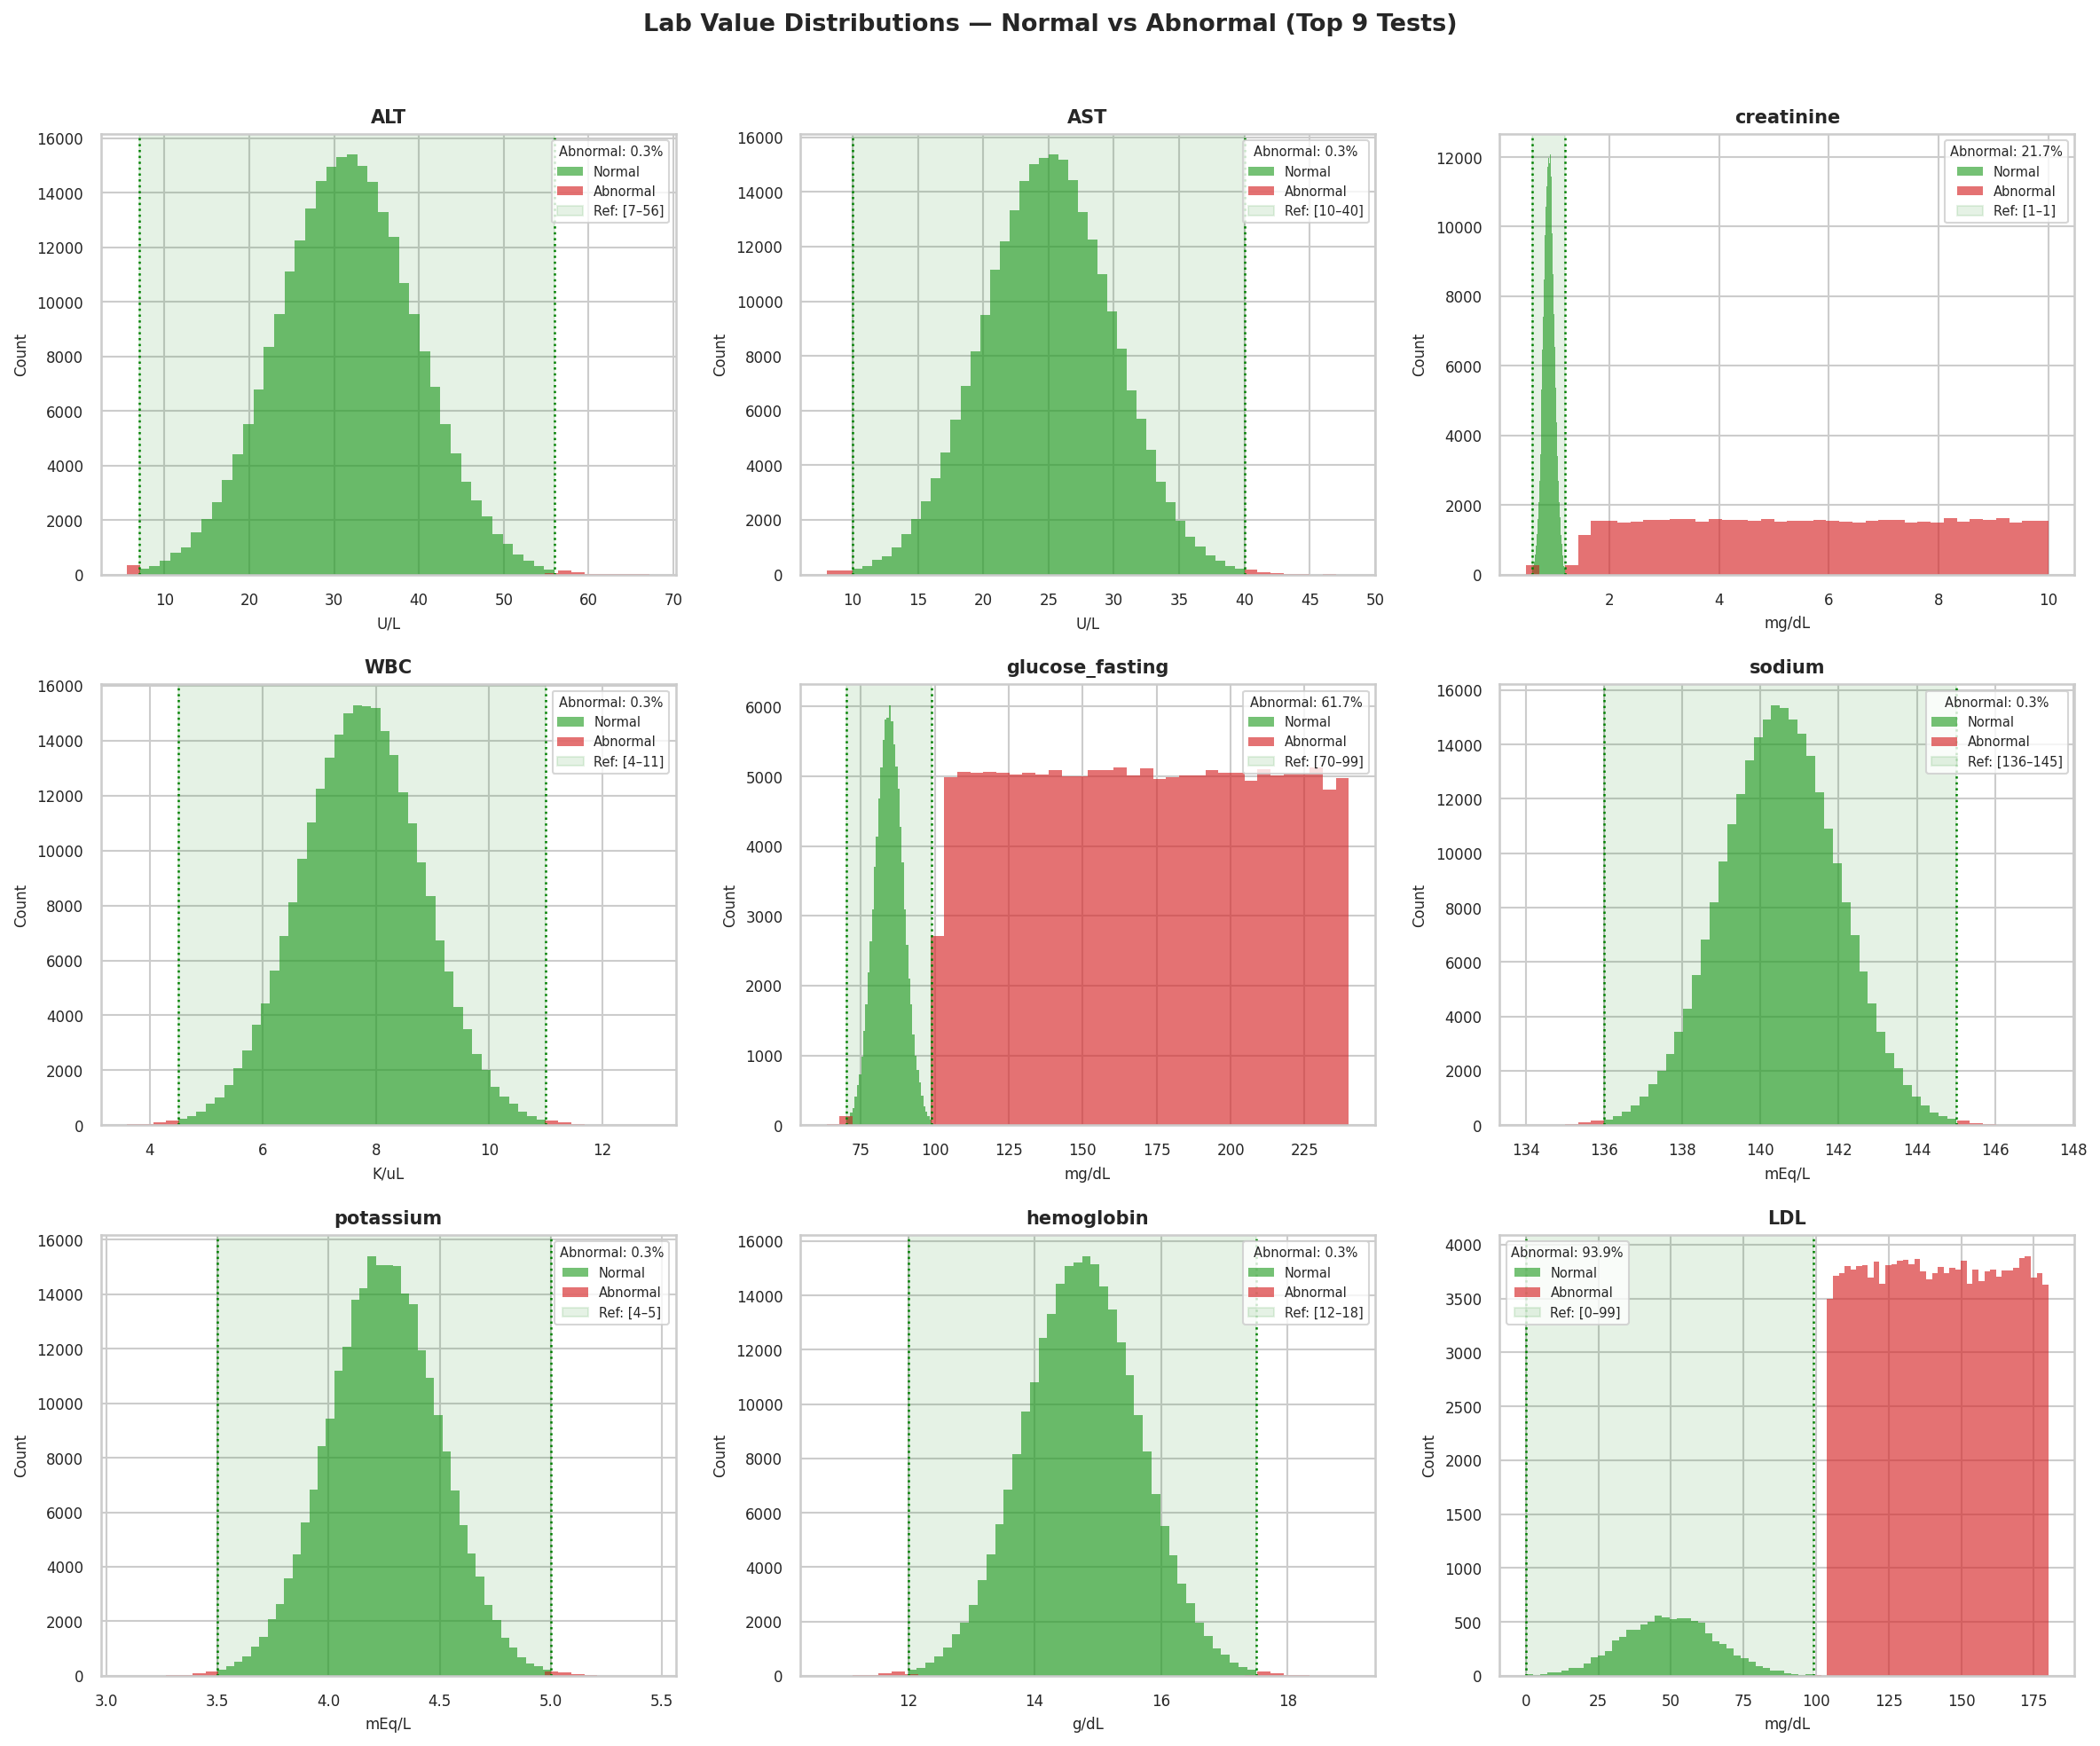

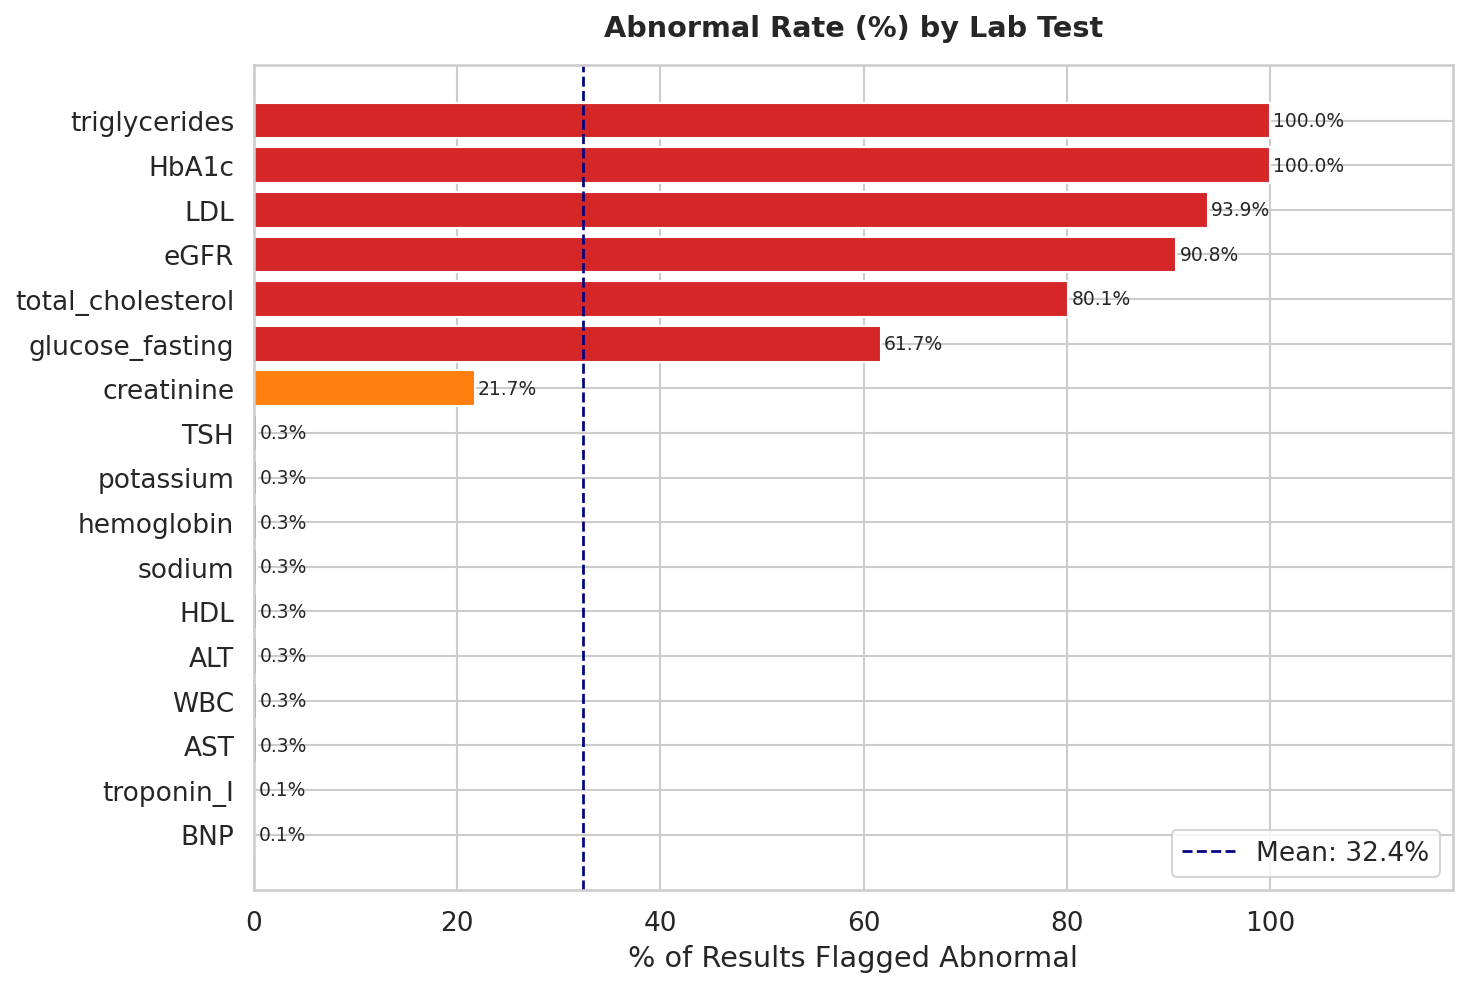

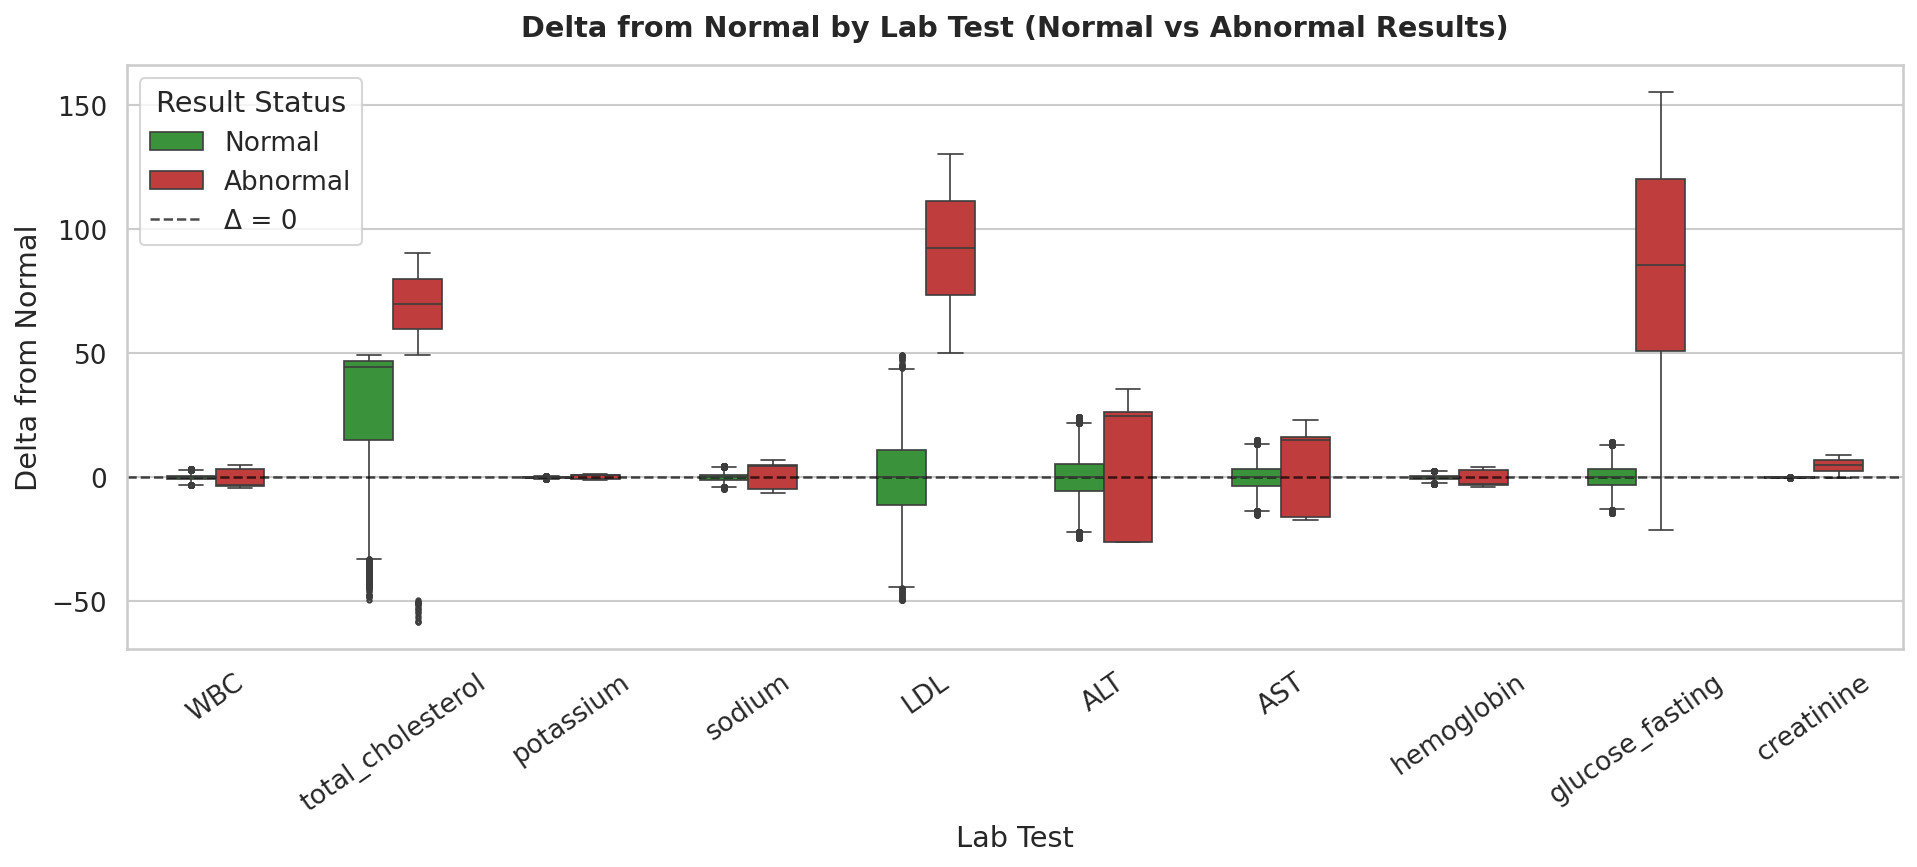

In [ ]:
# 5.1 Lab test overview
test_summary = (
    lab_results_df.groupby("test_name")
    .agg(n_results = ("value", "count"), mean_value    = ("value", "mean"), pct_abnormal  = ("is_abnormal", "mean"))
    .assign(pct_abnormal =lambda x: x["pct_abnormal"] * 100)
    .sort_values("n_results", ascending=False)
    .reset_index())
print("Lab Test Summary (top 15):")
print(test_summary.head(15).to_string(index=False))

TOP_TESTS = test_summary.head(9)["test_name"].tolist()

# 5.2 Distribution of Lab Values (top 9 tests)
fig, axes = plt.subplots(3, 3, figsize=(16, 13), dpi=FIG_DPI)
axes = axes.flatten()

for idx, test in enumerate(TOP_TESTS):
    ax = axes[idx]
    sub = lab_results_df[lab_results_df["test_name"] == test].copy()
    normal    = sub[sub["is_abnormal"] == 0]["value"]
    abnormal  = sub[sub["is_abnormal"] == 1]["value"]
    ax.hist(normal,   bins=40, alpha=0.65, color="#2CA02C", label="Normal",   edgecolor="none")
    ax.hist(abnormal, bins=40, alpha=0.65, color="#D62728", label="Abnormal", edgecolor="none")

    # Reference range shading
    ref_low  = sub["reference_low"].dropna().median()
    ref_high = sub["reference_high"].dropna().median()
    if pd.notna(ref_low) and pd.notna(ref_high):
        ax.axvspan(ref_low, ref_high, alpha=0.10, color="green", label=f"Ref: [{ref_low:.0f}–{ref_high:.0f}]")
        ax.axvline(ref_low,  color="green", linestyle=":", linewidth=1.2)
        ax.axvline(ref_high, color="green", linestyle=":", linewidth=1.2)

    unit_label = sub["unit"].mode()[0] if not sub["unit"].dropna().empty else ""
    ax.set_title(f"{test}", fontweight="bold", fontsize=10)
    ax.set_xlabel(unit_label, fontsize=8)
    ax.set_ylabel("Count", fontsize=8)
    ax.tick_params(labelsize=8)
    pct_abn = sub["is_abnormal"].mean() * 100
    ax.legend(fontsize=7, title=f"Abnormal: {pct_abn:.1f}%", title_fontsize=7)

# Hide any unused subplots
for j in range(len(TOP_TESTS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Lab Value Distributions — Normal vs Abnormal (Top 9 Tests)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("lab_distributions.png", bbox_inches="tight", dpi=FIG_DPI)
plt.show()

# 5.3 Abnormal Rate by Test
abn_rate = (lab_results_df.groupby("test_name")["is_abnormal"] .mean() .mul(100) .sort_values(ascending=True))
fig, ax = plt.subplots(figsize=(10, max(5, len(abn_rate) * 0.4)), dpi=FIG_DPI)
colors = ["#D62728" if v >= 30 else "#FF7F0E" if v >= 15 else "#2CA02C" for v in abn_rate.values]
bars = ax.barh(abn_rate.index, abn_rate.values, color=colors, edgecolor="white")

for bar, val in zip(bars, abn_rate.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2, f"{val:.1f}%", va="center", fontsize=9)

ax.axvline(abn_rate.mean(), color="navy", linestyle="--", linewidth=1.3, label=f"Mean: {abn_rate.mean():.1f}%")
ax.set_title("Abnormal Rate (%) by Lab Test", fontweight="bold", pad=TITLE_PAD)
ax.set_xlabel("% of Results Flagged Abnormal")
ax.legend()
ax.set_xlim(0, abn_rate.max() * 1.18)
plt.tight_layout()
plt.savefig("lab_abnormal_rate.png", bbox_inches="tight", dpi=FIG_DPI)
plt.show()

# 5.4 Delta from Normal — Box Plot
top10_tests = test_summary.head(10)["test_name"].tolist()
lab_top10 = lab_results_df[lab_results_df["test_name"].isin(top10_tests)]

fig, ax = plt.subplots(figsize=(13, 6), dpi=FIG_DPI)
sns.boxplot(data=lab_top10, x="test_name", y="delta_from_normal", hue="is_abnormal",
            palette={0: "#2CA02C", 1: "#D62728"}, width=0.55, fliersize=2, linewidth=0.8, ax=ax)
ax.axhline(0, color="black", linestyle="--", linewidth=1.2, alpha=0.7, label="Normal threshold (Δ = 0)")
ax.set_title("Delta from Normal by Lab Test (Normal vs Abnormal Results)", fontweight="bold", pad=TITLE_PAD)
ax.set_xlabel("Lab Test")
ax.set_ylabel("Delta from Normal")
ax.tick_params(axis="x", rotation=35)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ["Normal", "Abnormal", "Δ = 0"], title="Result Status")
plt.tight_layout()
plt.savefig("lab_delta_from_normal.png", bbox_inches="tight", dpi=FIG_DPI)
plt.show()

# SECTION 6 — MEDICATION PATTERN ANALYSIS

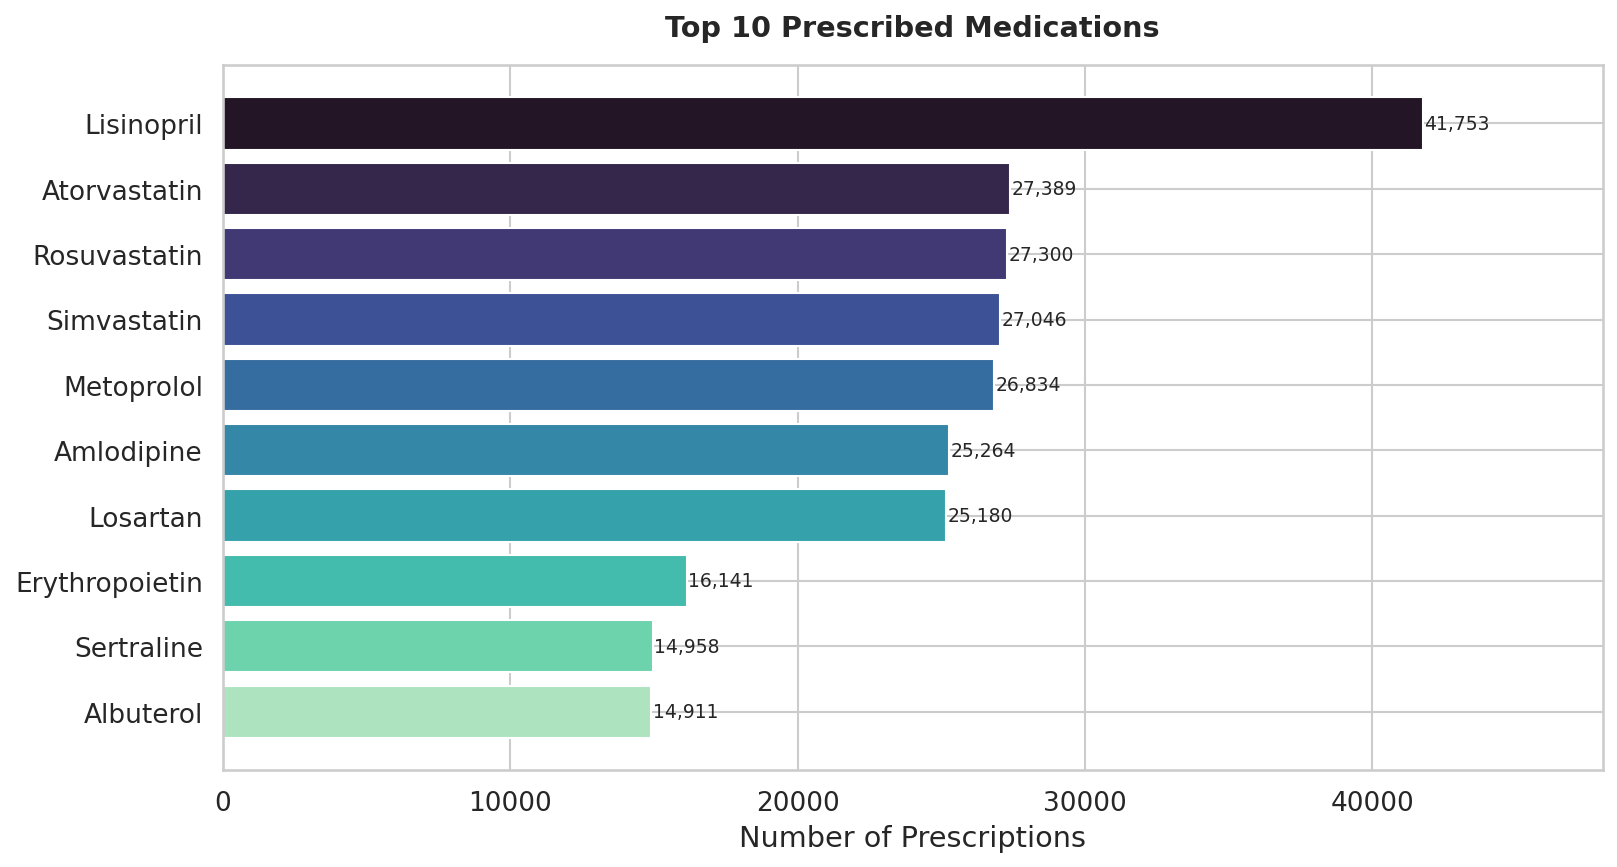

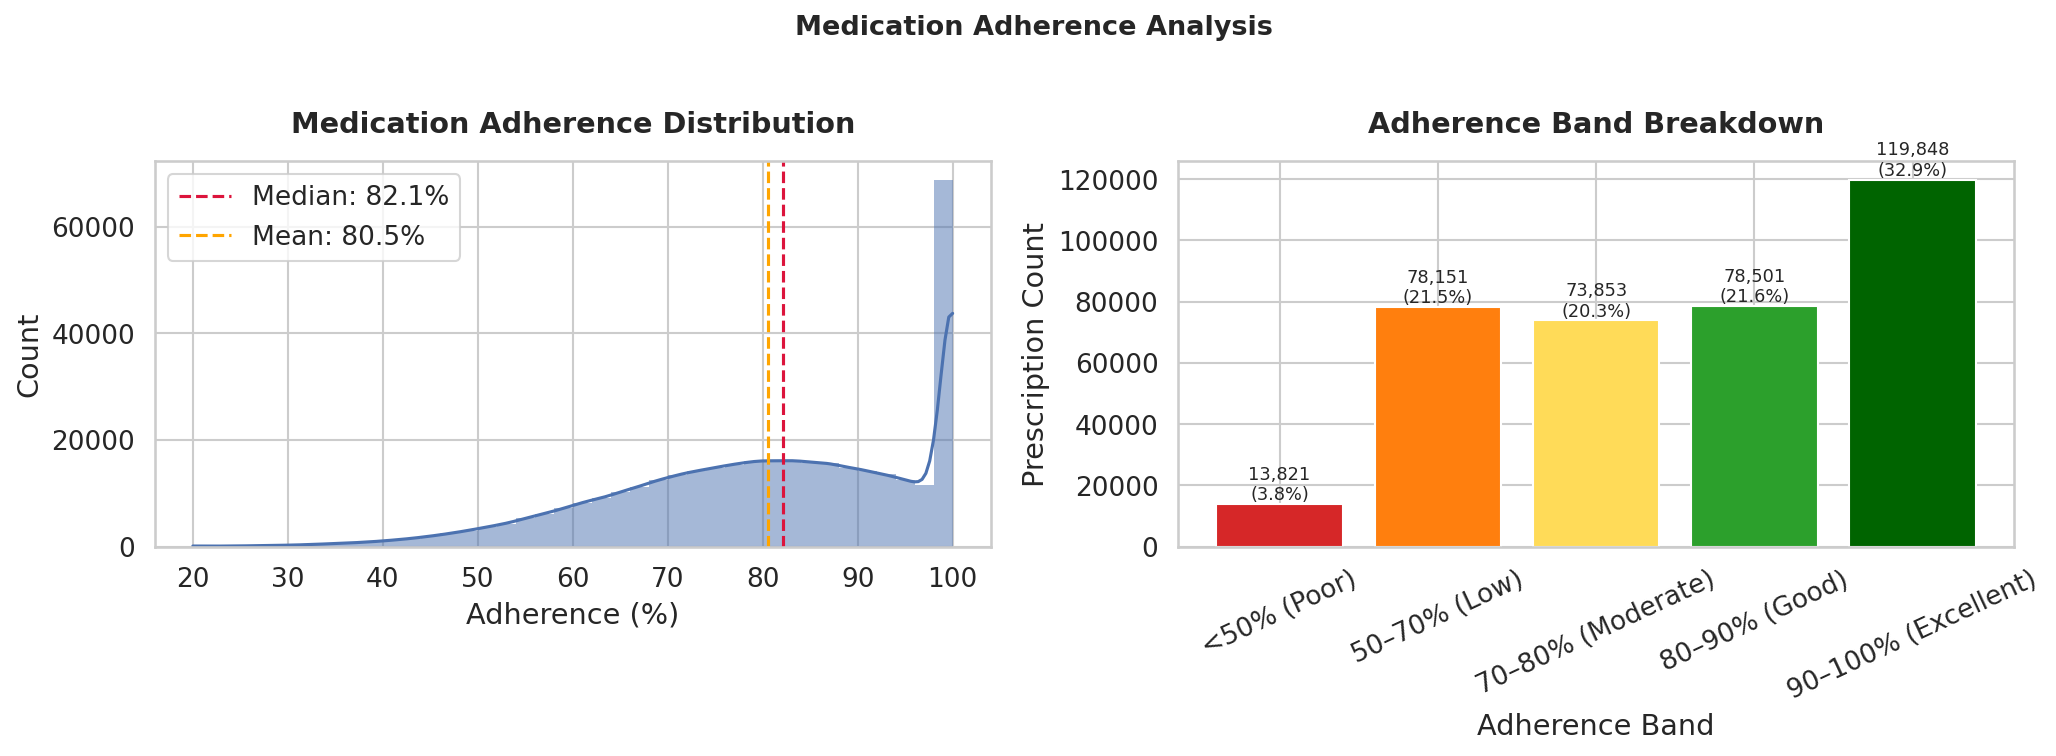

In [ ]:
# 6.1 Top 10 Prescribed Medications
top_meds = (
    medications_df["medication"]
    .value_counts()
    .head(10)
    .reset_index()
    .rename(columns={"index": "medication", "medication": "prescription_count"}))

# Compatible with both old and new pandas value_counts column naming
if "count" in top_meds.columns:
    top_meds.columns = ["medication", "prescription_count"]

fig, ax = plt.subplots(figsize=(11, 6), dpi=FIG_DPI)
colors = sns.color_palette("mako_r", len(top_meds))
bars = ax.barh(top_meds["medication"][::-1], top_meds["prescription_count"][::-1], color=colors, edgecolor="white")

for bar, val in zip(bars, top_meds["prescription_count"][::-1]):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
            f"{int(val):,}", va="center", fontsize=9)

ax.set_title("Top 10 Prescribed Medications", fontweight="bold", pad=TITLE_PAD)
ax.set_xlabel("Number of Prescriptions")
ax.set_xlim(0, top_meds["prescription_count"].max() * 1.15)
plt.tight_layout()
plt.savefig("meds_top10.png", bbox_inches="tight", dpi=FIG_DPI)
plt.show()

# 6.2 Medication Adherence Distribution
adherence_bins = [0, 50, 70, 80, 90, 100]
adherence_labels = ["<50% (Poor)", "50–70% (Low)", "70–80% (Moderate)",
                    "80–90% (Good)", "90–100% (Excellent)"]
medications_df["adherence_band"] = pd.cut(medications_df["adherence_pct"], bins=adherence_bins, labels=adherence_labels, right=True,)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=FIG_DPI)

# KDE
sns.histplot(medications_df["adherence_pct"], bins=40, kde=True,
             color="#4C72B0", edgecolor="none", ax=axes[0])
axes[0].axvline(medications_df["adherence_pct"].median(), color="crimson", linestyle="--", linewidth=1.5,
                label=f"Median: {medications_df['adherence_pct'].median():.1f}%")
axes[0].axvline(medications_df["adherence_pct"].mean(), color="orange", linestyle="--", linewidth=1.5,
                label=f"Mean: {medications_df['adherence_pct'].mean():.1f}%")
axes[0].set_title("Medication Adherence Distribution", fontweight="bold", pad=TITLE_PAD)
axes[0].set_xlabel("Adherence (%)")
axes[0].set_ylabel("Count")
axes[0].legend()

# Adherence band bar
adh_band_counts = medications_df["adherence_band"].value_counts().reindex(adherence_labels)
band_colors = ["#D62728", "#FF7F0E", "#FFDB58", "#2CA02C", "#006400"]
bars = axes[1].bar(adherence_labels, adh_band_counts.values, color=band_colors, edgecolor="white")

for bar, val in zip(bars, adh_band_counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
                 f"{int(val):,}\n({val/len(medications_df)*100:.1f}%)", ha="center", va="bottom", fontsize=8.5)

axes[1].set_title("Adherence Band Breakdown", fontweight="bold", pad=TITLE_PAD)
axes[1].set_xlabel("Adherence Band")
axes[1].set_ylabel("Prescription Count")
axes[1].tick_params(axis="x", rotation=25)
plt.suptitle("Medication Adherence Analysis", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("meds_adherence.png", bbox_inches="tight", dpi=FIG_DPI)
plt.show()

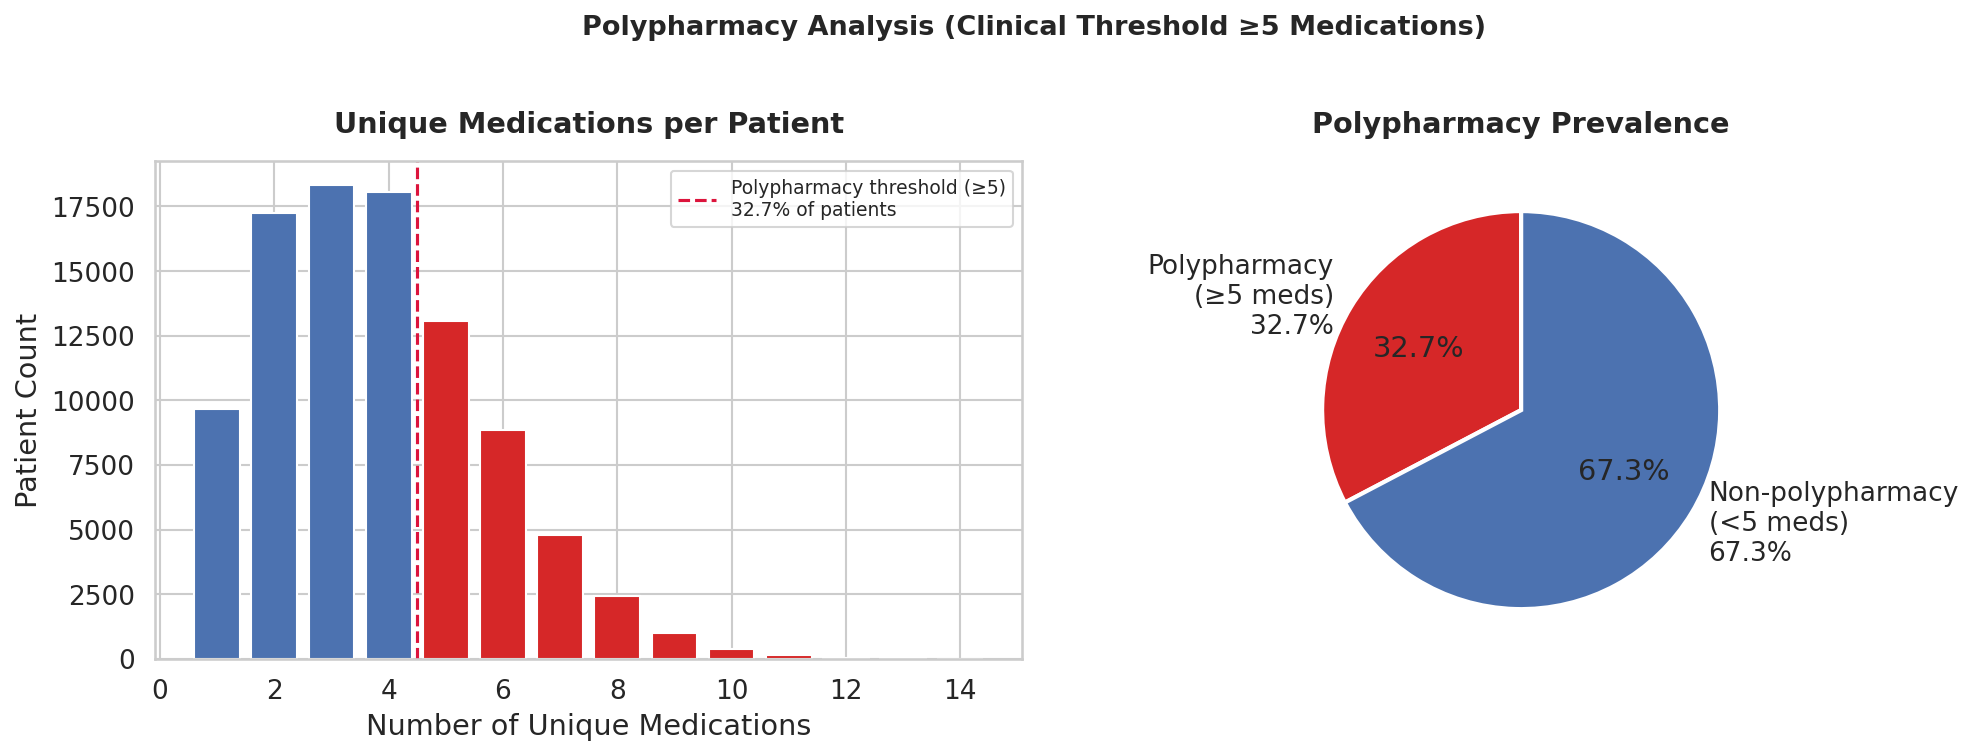


Polypharmacy Summary:
  Total patients with prescriptions : 94,067
  Polypharmacy patients (≥5 meds)   : 30,749  (32.7%)
  Max unique meds per patient        : 14
  Mean unique meds per patient       : 3.81


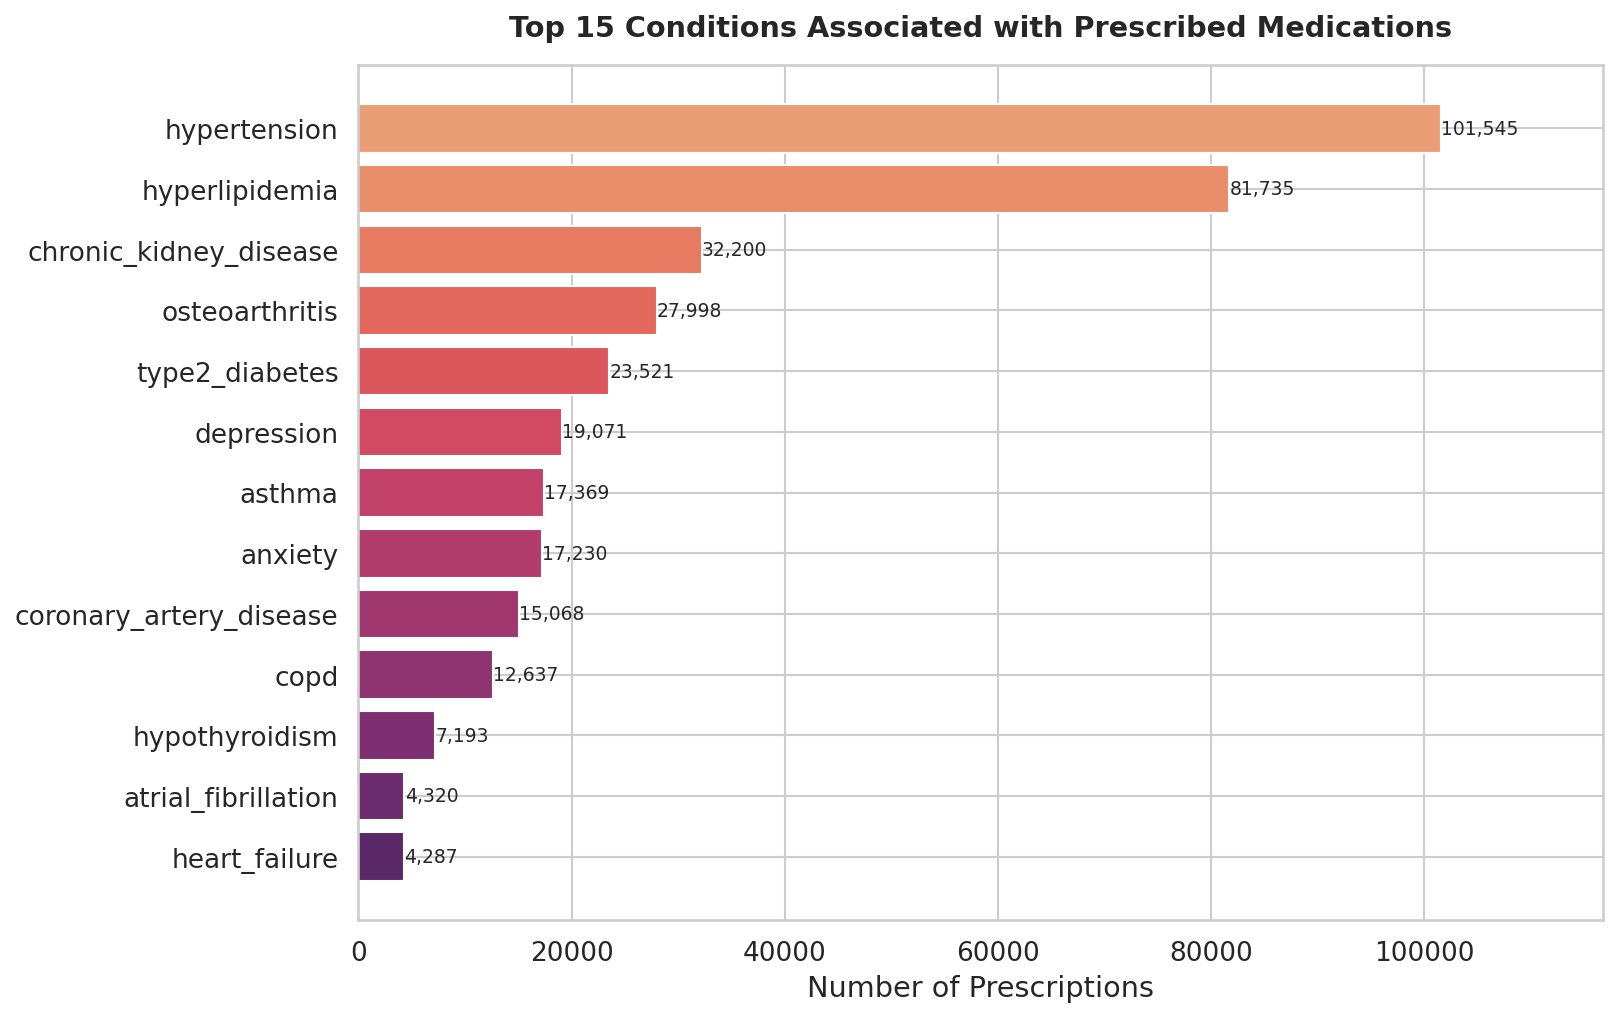

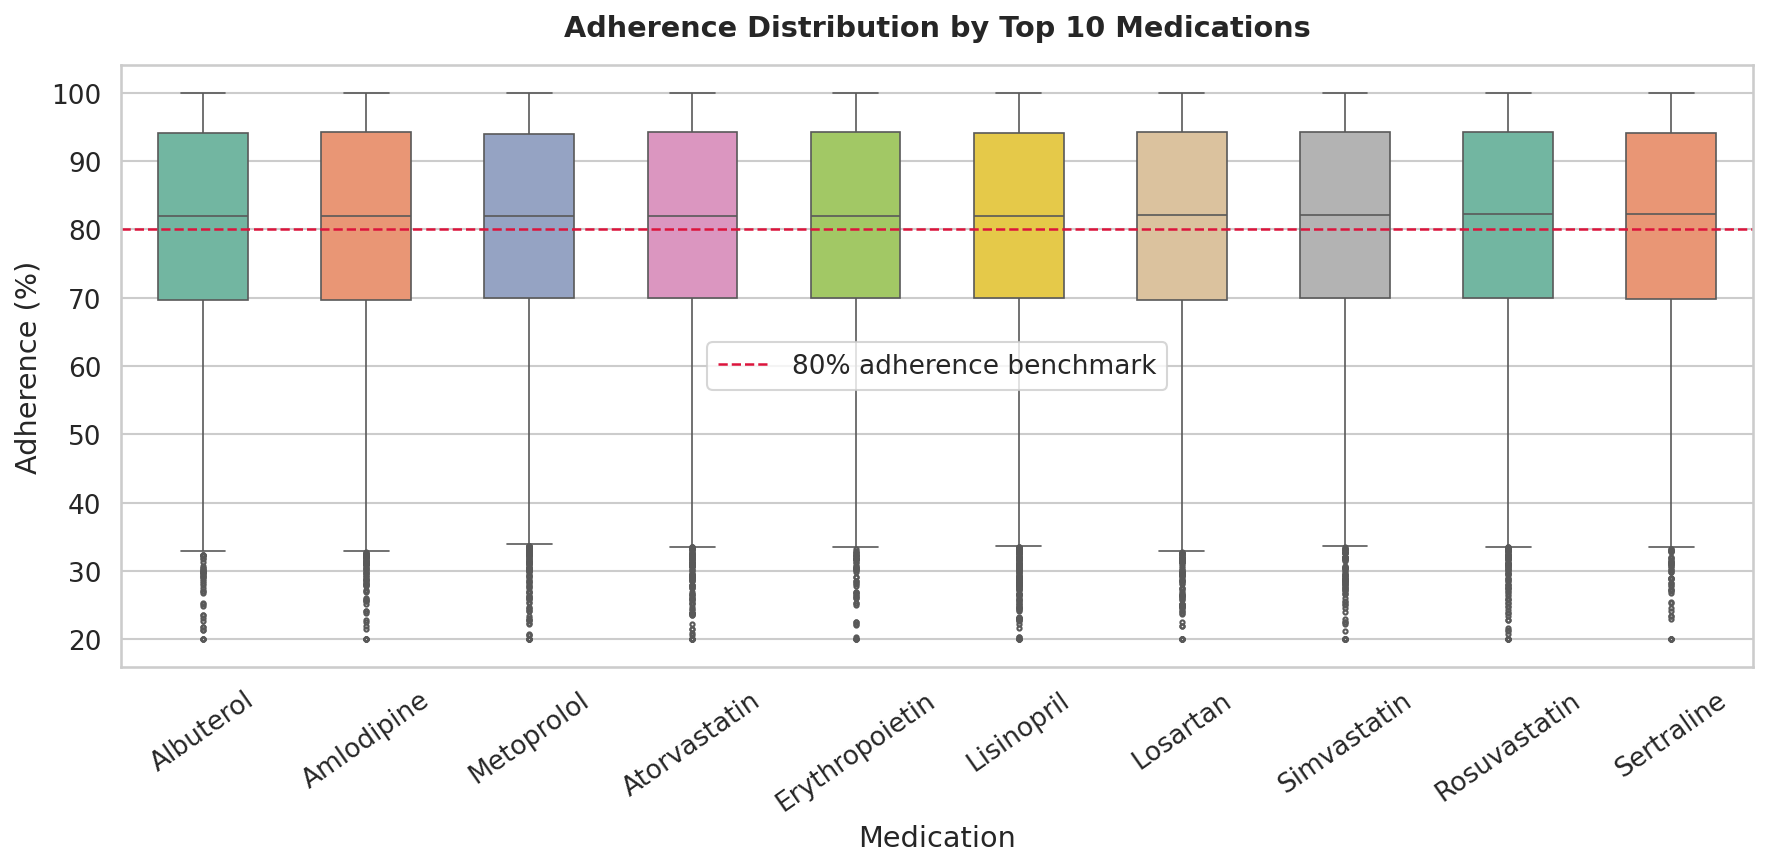


  ✅  ANALYSIS COMPLETE


In [ ]:
# 6.3 Polypharmacy Analysis
med_count_per_patient = (
    medications_df.groupby("patient_id")["medication"]
    .nunique()
    .reset_index()
    .rename(columns={"medication": "unique_medications"}))

# Polypharmacy = ≥5 concurrent unique medications (standard clinical threshold)
polypharmacy_patients = med_count_per_patient[med_count_per_patient["unique_medications"] >= 5]
polypharmacy_pct = len(polypharmacy_patients) / len(med_count_per_patient) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=FIG_DPI)

# Distribution
ax_hist = axes[0]
count_dist_med = med_count_per_patient["unique_medications"].value_counts().sort_index()
colors_poly    = ["#D62728" if i >= 5 else "#4C72B0" for i in count_dist_med.index]
ax_hist.bar(count_dist_med.index, count_dist_med.values, color=colors_poly, edgecolor="white")
ax_hist.axvline(4.5, color="crimson", linestyle="--", linewidth=1.5, label=f"Polypharmacy threshold (≥5)\n{polypharmacy_pct:.1f}% of patients")
ax_hist.set_title("Unique Medications per Patient", fontweight="bold", pad=TITLE_PAD)
ax_hist.set_xlabel("Number of Unique Medications")
ax_hist.set_ylabel("Patient Count")
ax_hist.legend(fontsize=9)
ax_hist.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Polypharmacy vs normal
poly_summary = pd.Series(
    {f"Polypharmacy\n(≥5 meds)\n{polypharmacy_pct:.1f}%": len(polypharmacy_patients),
    f"Non-polypharmacy\n(<5 meds)\n{100 - polypharmacy_pct:.1f}%":
     (len(med_count_per_patient) - len(polypharmacy_patients)),})

axes[1].pie(poly_summary.values, labels=poly_summary.index, colors=["#D62728", "#4C72B0"],
            autopct="%1.1f%%", startangle=90, wedgeprops=dict(edgecolor="white", linewidth=2))
axes[1].set_title("Polypharmacy Prevalence", fontweight="bold", pad=TITLE_PAD)

plt.suptitle("Polypharmacy Analysis (Clinical Threshold ≥5 Medications)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("meds_polypharmacy.png", bbox_inches="tight", dpi=FIG_DPI)
plt.show()
print(f"\nPolypharmacy Summary:")
print(f"  Total patients with prescriptions : {len(med_count_per_patient):,}")
print(f"  Polypharmacy patients (≥5 meds)   : {len(polypharmacy_patients):,}  ({polypharmacy_pct:.1f}%)")
print(f"  Max unique meds per patient        : {med_count_per_patient['unique_medications'].max()}")
print(f"  Mean unique meds per patient       : {med_count_per_patient['unique_medications'].mean():.2f}")

# 6.4 Top Conditions Associated with Medications
top_indications = (medications_df["indication"] .str.strip() .value_counts() .head(15) .reset_index())
top_indications.columns = ["indication", "count"]

fig, ax = plt.subplots(figsize=(11, 7), dpi=FIG_DPI)

colors = sns.color_palette("flare", len(top_indications))
bars   = ax.barh(top_indications["indication"][::-1], top_indications["count"][::-1], color=colors[::-1], edgecolor="white")

for bar, val in zip(bars, top_indications["count"][::-1]):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height() / 2,
            f"{int(val):,}", va="center", fontsize=9)

ax.set_title("Top 15 Conditions Associated with Prescribed Medications", fontweight="bold", pad=TITLE_PAD)
ax.set_xlabel("Number of Prescriptions")
ax.set_xlim(0, top_indications["count"].max() * 1.15)
plt.tight_layout()
plt.savefig("meds_top_indications.png", bbox_inches="tight", dpi=FIG_DPI)
plt.show()

# 6.5 Adherence by Top 10 Medications
top10_med_names = medications_df["medication"].value_counts().head(10).index.tolist()
adh_by_med      = medications_df[medications_df["medication"].isin(top10_med_names)]

med_order = (adh_by_med.groupby("medication")["adherence_pct"] .median() .sort_values() .index.tolist())

fig, ax = plt.subplots(figsize=(12, 6), dpi=FIG_DPI)
sns.boxplot(data=adh_by_med, x="medication", y="adherence_pct", order=med_order, palette="Set2", width=0.55, fliersize=2, linewidth=0.8, ax=ax)

ax.axhline(80, color="crimson", linestyle="--", linewidth=1.2, label="80% adherence benchmark")
ax.set_title("Adherence Distribution by Top 10 Medications", fontweight="bold", pad=TITLE_PAD)
ax.set_xlabel("Medication")
ax.set_ylabel("Adherence (%)")
ax.tick_params(axis="x", rotation=35)
ax.legend()
plt.tight_layout()
plt.savefig("meds_adherence_by_drug.png", bbox_inches="tight", dpi=FIG_DPI)
plt.show()

print("\n" + "=" * 60)
print("  ✅  ANALYSIS COMPLETE")

# SECTION 7 - ICD Based cormorbidity analysis
- to understand which conditions frequently occur together and the recurrence

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import os

sns.set_theme(style="whitegrid", palette="muted", font_scale=0.9)

path = '/content/drive/MyDrive/med_dataset'

df = pd.read_csv(os.path.join(path, "diagnoses.csv"))
df["year"] = pd.to_datetime(df["visit_date"]).dt.year
icd_label = df.groupby("primary_icd10")["primary_diagnosis"].first()
primary_counts = df["primary_icd10"].value_counts()
freq_df = pd.DataFrame({"icd": primary_counts.index,"count": primary_counts.values,"diagnosis": [icd_label.get(i, i).replace("_", " ").title() for i in primary_counts.index]})

# ICD Frequency
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(freq_df["diagnosis"], freq_df["count"], color=sns.color_palette("mako", len(freq_df)))
ax.set_xlabel("Visit count")
ax.set_title("Primary ICD-10 Code Frequency")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
for bar, icd in zip(bars, freq_df["icd"]):
    ax.text(bar.get_width() + 300, bar.get_y() + bar.get_height()/2,
            icd, va="center", fontsize=8, color="gray")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("primary_icd_frequency.png", dpi=300)
plt.show()

# Primary vs Secondary
sec_counts = (df[df["secondary_icd10s"].notna()] .assign(sec=lambda d: d["secondary_icd10s"].str.split("|")) .explode("sec")["sec"].value_counts())
freq_df["secondary"] = freq_df["icd"].map(sec_counts).fillna(0).astype(int)
freq_df_s = freq_df.sort_values("count", ascending=False)
x = range(len(freq_df_s))
w = 0.4
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar([i - w/2 for i in x], freq_df_s["count"],     width=w, label="Primary",   color="#1D9E75")
ax.bar([i + w/2 for i in x], freq_df_s["secondary"], width=w, label="Secondary", color="#378ADD")
ax.set_xticks(list(x))
ax.set_xticklabels(freq_df_s["diagnosis"], rotation=40, ha="right", fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v/1000)}k"))
ax.set_title("Primary vs Secondary Occurrence")
ax.legend()
plt.tight_layout()
plt.savefig("primary_vs_secondary_occurrence.png", dpi=300)
plt.show()

# Co-occurrence Heatmap
top_conds = ["hypertension","obesity","hyperlipidemia","chronic_kidney_disease","type2_diabetes","osteoarthritis","depression","coronary_artery_disease","anxiety","asthma","copd"]
short = ["HTN","Obesity","Hyperlipid.","CKD","T2DM","OA","Depression","CAD","Anxiety","Asthma","COPD"]
co = Counter()
for _, row in df.iterrows():
    conds = [row["primary_diagnosis"]]
    if pd.notna(row["secondary_diagnoses"]):
        conds += row["secondary_diagnoses"].split("|")
    conds = list(set(c.strip() for c in conds if c.strip() in top_conds))
    for i in range(len(conds)):
        for j in range(i+1, len(conds)):
            co[tuple(sorted([conds[i], conds[j]]))] += 1

mat = pd.DataFrame(0, index=short, columns=short)
for (a, b), v in co.items():
    if a in top_conds and b in top_conds:
        sa, sb = short[top_conds.index(a)], short[top_conds.index(b)]
        mat.loc[sa, sb] = v
        mat.loc[sb, sa] = v
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(mat, ax=ax, cmap="YlGnBu", fmt=",d", annot=True, annot_kws={"size": 7}, linewidths=0.3, linecolor="white", cbar_kws={"shrink": 0.6})
ax.set_title("Condition Co-occurrence Heatmap")
plt.tight_layout()
plt.savefig("condition_cooccurrence_heatmap.png", dpi=300)
plt.show()

# Year Trend
top10 = top_conds[:10]
trend = (df[df["primary_diagnosis"].isin(top10)].groupby(["year","primary_diagnosis"]).size().reset_index(name="count"))
trend["diagnosis"] = trend["primary_diagnosis"].str.replace("_", " ").str.title()
fig, ax = plt.subplots(figsize=(12, 5))
for cond, grp in trend.groupby("diagnosis"):
    ax.plot(grp["year"], grp["count"], marker="o", label=cond, linewidth=1.8)
ax.set_title("Primary Diagnosis Trend 2018–2024")
ax.set_xlabel("Year")
ax.set_ylabel("Visit count")
ax.legend(fontsize=7, ncol=2)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.tight_layout()
plt.savefig("primary_diagnosis_trend.png", dpi=300)
plt.show()

# Visit Type & Specialty
vt = df["visit_type"].value_counts()
sp = df["provider_specialty"].value_counts()
colors = sns.color_palette("Set2")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].pie(vt.values, labels=vt.index, autopct="%1.1f%%", colors=colors, startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[0].set_title("Visit Types")
axes[1].pie(sp.values, labels=sp.index, autopct="%1.1f%%", colors=colors, startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[1].set_title("Provider Specialties")
plt.tight_layout()
plt.savefig("visit_type_and_specialty.png", dpi=300)
plt.show()

# DASHBOARD

In [ ]:
# =============================================================================
# PATIENT RECORDS — CLINICAL ANALYTICS DASHBOARD GENERATOR
# Output: patient_dashboard.html  (fully self-contained, no internet needed)
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import base64, io, textwrap, warnings
from datetime import datetime

warnings.filterwarnings("ignore")

# Plot style
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.facecolor":  "#ffffff",
    "axes.facecolor":    "#f8fafc",
    "axes.edgecolor":    "#e2e8f0",
    "axes.labelcolor":   "#334155",
    "xtick.color":       "#64748b",
    "ytick.color":       "#64748b",
    "text.color":        "#1e293b",
    "grid.color":        "#e2e8f0",
    "grid.linewidth":    0.7,
    "axes.titlecolor":   "#0f172a",
    "axes.titleweight":  "bold",
    "axes.titlesize":    12,
})

ACCENT  = "#0ea5e9"    # sky-500
GREEN   = "#16a34a"    # green-700
RED     = "#dc2626"    # red-600
ORANGE  = "#ea580c"    # orange-600
PURPLE  = "#7c3aed"    # violet-700
YELLOW  = "#ca8a04"    # yellow-600
FIG_DPI = 130

DX_COLS = [c for c in patients_df.columns if c.startswith("dx_")]
DX_LABELS = {c: c.replace("dx_", "").replace("_", " ").title() for c in DX_COLS}


# Helper: fig → base64 PNG
def fig_to_b64(fig) -> str:
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=FIG_DPI, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    buf.seek(0)
    encoded = base64.b64encode(buf.read()).decode("utf-8")
    plt.close(fig)
    return f"data:image/png;base64,{encoded}"

print("🔬 Generating charts…")

# =============================================================================
# CHART 01 — Age Distribution by Sex
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sex_pal = {"M": ACCENT, "F": PURPLE}
for sex, grp in patients_df.groupby("sex"):
    axes[0].hist(grp["age"], bins=32, alpha=0.70,
                 color=sex_pal.get(sex, "grey"), label=sex, edgecolor="none")
axes[0].set_title("Age Distribution by Sex")
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Patients")
axes[0].legend(title="Sex")

sns.boxplot(data=patients_df, x="sex", y="age", palette=sex_pal,
            width=0.45, ax=axes[1], linewidth=0.9)
for i, sex in enumerate(patients_df["sex"].unique()):
    med = patients_df.loc[patients_df["sex"] == sex, "age"].median()
    axes[1].text(i, med + 1.5, f"{med:.0f}", ha="center", fontsize=9, color="#0f172a")
axes[1].set_title("Age Spread by Sex")
axes[1].set_xlabel("Sex"); axes[1].set_ylabel("Age (years)")
fig.tight_layout(pad=2)
C01 = fig_to_b64(fig)

# =============================================================================
# CHART 02 — Insurance Type Distribution
# =============================================================================
ins = patients_df["insurance_type"].value_counts()
ins_colors = [ACCENT, PURPLE, GREEN, ORANGE, RED, YELLOW]
fig, ax = plt.subplots(figsize=(7, 5))
wedges, texts, autotexts = ax.pie(
    ins.values, labels=ins.index,
    colors=ins_colors[:len(ins)], autopct="%1.1f%%",
    startangle=140, pctdistance=0.78,
    wedgeprops=dict(edgecolor="#ffffff", linewidth=2.5),
)
for at in autotexts: at.set_fontsize(9); at.set_color("#ffffff")
ax.set_title("Insurance Type Distribution")
centre = plt.Circle((0,0), 0.52, color="#ffffff")
ax.add_artist(centre)
ax.text(0, 0, f"{len(patients_df):,}\nPatients", ha="center", va="center",
        fontsize=11, color="#0f172a", fontweight="bold")
fig.tight_layout()
C02 = fig_to_b64(fig)

# =============================================================================
# CHART 03 — BMI Distribution
# =============================================================================
bmi_bins   = [0, 18.5, 25, 30, 35, 40, np.inf]
bmi_labels = ["Under-\nweight", "Normal", "Over-\nweight",
              "Obese I", "Obese II", "Obese III"]
patients_df["bmi_category"] = pd.cut(patients_df["bmi"], bins=bmi_bins,
                                      labels=bmi_labels, right=False)
cat_counts = patients_df["bmi_category"].value_counts().reindex(bmi_labels)
cat_colors = [ACCENT, GREEN, YELLOW, ORANGE, RED, "#be123c"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(patients_df["bmi"].dropna(), bins=50, color=ACCENT,
             alpha=0.80, edgecolor="none")
for x in bmi_bins[1:-1]:
    axes[0].axvline(x, color=RED, linestyle="--", linewidth=1, alpha=0.6)
axes[0].set_title("BMI Distribution with Category Boundaries")
axes[0].set_xlabel("BMI (kg/m²)"); axes[0].set_ylabel("Patients")

bars = axes[1].bar(bmi_labels, cat_counts.values, color=cat_colors, edgecolor="none")
for bar, val in zip(bars, cat_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
                 f"{val:,}", ha="center", fontsize=8, color="#1e293b")
axes[1].set_title("Patients by BMI Category")
axes[1].set_xlabel("Category"); axes[1].set_ylabel("Patients")
fig.tight_layout(pad=2)
C03 = fig_to_b64(fig)

# =============================================================================
# CHART 04 — Lifestyle Factors
# =============================================================================
ex_order  = ["sedentary", "light", "moderate", "active"]
ex_counts = patients_df["exercise_level"].str.lower().value_counts()\
              .reindex(ex_order).fillna(0)
sm_order  = ["current", "former", "never"]
sm_counts = patients_df["smoking_status"].str.lower().value_counts()\
              .reindex(sm_order).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ex_pal = [RED, ORANGE, GREEN, ACCENT]
bars = axes[0].barh(ex_order[::-1],
                    ex_counts.reindex(ex_order[::-1]).values,
                    color=ex_pal[::-1], edgecolor="none")
for bar, val in zip(bars, ex_counts.reindex(ex_order[::-1]).values):
    axes[0].text(bar.get_width()+150, bar.get_y()+bar.get_height()/2,
                 f"{int(val):,}  ({val/len(patients_df)*100:.1f}%)",
                 va="center", fontsize=9)
axes[0].set_title("Exercise Level Distribution")
axes[0].set_xlabel("Patients"); axes[0].set_ylabel("Exercise Level")

sm_colors = [RED, ORANGE, GREEN]
wedges, texts, at = axes[1].pie(sm_counts.values,
    labels=[f"{l.title()}\n({v:,.0f})" for l,v in zip(sm_order, sm_counts.values)],
    colors=sm_colors, autopct="%1.1f%%", startangle=130,
    wedgeprops=dict(edgecolor="#ffffff", linewidth=2.5))
for a in at: a.set_fontsize(9); a.set_color("#ffffff")
axes[1].set_title("Smoking Status Distribution")
fig.tight_layout(pad=2)
C04 = fig_to_b64(fig)

# =============================================================================
# CHART 05 — Disease Prevalence
# =============================================================================
prevalence = (patients_df[DX_COLS].sum()/len(patients_df)*100)\
              .rename(DX_LABELS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
bar_colors = [RED if v >= prevalence.quantile(0.75)
              else ORANGE if v >= prevalence.median()
              else ACCENT for v in prevalence.values]
bars = ax.barh(prevalence.index, prevalence.values, color=bar_colors, edgecolor="none")
for bar, val in zip(bars, prevalence.values):
    ax.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=8.5)
ax.axvline(prevalence.mean(), color=YELLOW, linestyle="--", linewidth=1.3,
           label=f"Mean {prevalence.mean():.1f}%")
ax.set_title("Disease Prevalence in Patient Population")
ax.set_xlabel("Prevalence (%)"); ax.legend()
ax.set_xlim(0, prevalence.max()*1.15)
fig.tight_layout()
C05 = fig_to_b64(fig)

# =============================================================================
# CHART 06 — Co-occurrence Heatmap
# =============================================================================
corr = patients_df[DX_COLS].rename(columns=DX_LABELS).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap=cmap,
            center=0, vmin=-0.3, vmax=0.6, linewidths=0.4,
            linecolor="#ffffff", annot_kws={"size": 7},
            ax=ax, cbar_kws={"shrink": 0.7, "label": "φ correlation"})
ax.set_title("Disease Co-occurrence Correlation Matrix")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0,  labelsize=8)
fig.tight_layout()
C06 = fig_to_b64(fig)

# =============================================================================
# CHART 07 — Prevalence by Age Group
# =============================================================================
age_bins   = [0, 30, 45, 60, 75, np.inf]
age_labels = ["<30", "30–44", "45–59", "60–74", "75+"]
patients_df["age_group"] = pd.cut(patients_df["age"], bins=age_bins,
                                   labels=age_labels, right=False)
age_prev = (patients_df.groupby("age_group", observed=True)[DX_COLS]
            .mean()*100).rename(columns=DX_LABELS)

fig, ax = plt.subplots(figsize=(13, 7))
im = ax.imshow(age_prev.T.values, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(len(age_labels))); ax.set_xticklabels(age_labels)
ax.set_yticks(range(len(age_prev.columns))); ax.set_yticklabels(age_prev.columns, fontsize=8)
for i in range(age_prev.shape[1]):
    for j in range(age_prev.shape[0]):
        val = age_prev.T.values[i,j]
        ax.text(j, i, f"{val:.0f}%", ha="center", va="center",
                fontsize=7.5, color="white" if val > 40 else "#1e293b")
plt.colorbar(im, ax=ax, label="Prevalence (%)", shrink=0.6)
ax.set_title("Disease Prevalence by Age Group (%)")
ax.set_xlabel("Age Group")
fig.tight_layout()
C07 = fig_to_b64(fig)

# =============================================================================
# CHART 08 — Conditions per Patient
# =============================================================================
patients_df["condition_count"] = patients_df[DX_COLS].sum(axis=1)
count_dist = patients_df["condition_count"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
bar_c = [RED if i >= 5 else ACCENT for i in count_dist.index]
axes[0].bar(count_dist.index, count_dist.values, color=bar_c, edgecolor="none")
axes[0].axvline(4.5, color=RED, linestyle="--", linewidth=1.3,
                label="Polypharmacy (≥5)")
axes[0].set_title("Conditions per Patient")
axes[0].set_xlabel("# Conditions"); axes[0].set_ylabel("Patients")
axes[0].legend(); axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

cumulative = count_dist.cumsum()/count_dist.sum()*100
axes[1].plot(cumulative.index, cumulative.values, color=ACCENT,
             linewidth=2.5, marker="o", markersize=5)
axes[1].fill_between(cumulative.index, cumulative.values, alpha=0.12, color=ACCENT)
axes[1].axhline(80, color=RED, linestyle="--", linewidth=1.2, label="80% threshold")
axes[1].set_title("Cumulative % by Condition Count")
axes[1].set_xlabel("# Conditions (≤ x)"); axes[1].set_ylabel("Cumulative (%)")
axes[1].legend(); axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
fig.tight_layout(pad=2)
C08 = fig_to_b64(fig)

# =============================================================================
# CHART 09 — Lab Value Distributions
# =============================================================================
test_summary = (lab_results_df.groupby("test_name")
                .agg(n=("value","count"), pct_abn=("is_abnormal","mean"))
                .sort_values("n", ascending=False).reset_index())
TOP_TESTS = test_summary.head(9)["test_name"].tolist()

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()
for idx, test in enumerate(TOP_TESTS):
    ax = axes[idx]
    sub = lab_results_df[lab_results_df["test_name"] == test]
    ax.hist(sub.loc[sub["is_abnormal"]==0,"value"], bins=35,
            alpha=0.65, color=GREEN, label="Normal", edgecolor="none")
    ax.hist(sub.loc[sub["is_abnormal"]==1,"value"], bins=35,
            alpha=0.65, color=RED, label="Abnormal", edgecolor="none")
    rl = sub["reference_low"].median(); rh = sub["reference_high"].median()
    if pd.notna(rl) and pd.notna(rh):
        ax.axvspan(rl, rh, alpha=0.08, color=GREEN)
        ax.axvline(rl, color=GREEN, linestyle=":", linewidth=1)
        ax.axvline(rh, color=GREEN, linestyle=":", linewidth=1)
    unit = sub["unit"].mode()[0] if not sub["unit"].dropna().empty else ""
    pct  = sub["is_abnormal"].mean()*100
    ax.set_title(f"{test}  ({pct:.0f}% abn.)", fontsize=9)
    ax.set_xlabel(unit, fontsize=7.5); ax.set_ylabel("Count", fontsize=7.5)
    ax.tick_params(labelsize=7.5)
    ax.legend(fontsize=7)
for j in range(len(TOP_TESTS), 9): axes[j].set_visible(False)
fig.suptitle("Lab Value Distributions — Normal vs Abnormal", fontsize=12,
             fontweight="bold", y=1.01)
fig.tight_layout()
C09 = fig_to_b64(fig)

# =============================================================================
# CHART 10 — Abnormal Rate by Lab Test
# =============================================================================
abn_rate = (lab_results_df.groupby("test_name")["is_abnormal"]
            .mean().mul(100).sort_values(ascending=True))
bar_c_abn = [RED if v>=30 else ORANGE if v>=15 else GREEN for v in abn_rate.values]

fig, ax = plt.subplots(figsize=(10, max(5, len(abn_rate)*0.38)))
bars = ax.barh(abn_rate.index, abn_rate.values, color=bar_c_abn, edgecolor="none")
for bar, val in zip(bars, abn_rate.values):
    ax.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=8.5)
ax.axvline(abn_rate.mean(), color=YELLOW, linestyle="--", linewidth=1.3,
           label=f"Mean {abn_rate.mean():.1f}%")
ax.set_title("Abnormal Rate (%) by Lab Test")
ax.set_xlabel("% Flagged Abnormal"); ax.legend()
ax.set_xlim(0, abn_rate.max()*1.18)
fig.tight_layout()
C10 = fig_to_b64(fig)

# =============================================================================
# CHART 11 — Top 10 Medications
# =============================================================================
top_meds = medications_df["medication"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5.5))
colors_m = [ACCENT, PURPLE, GREEN, ORANGE, YELLOW,
            RED, "#22d3ee", "#a78bfa", "#86efac", "#fca5a5"]
bars = ax.barh(top_meds.index[::-1], top_meds.values[::-1],
               color=colors_m, edgecolor="none")
for bar, val in zip(bars, top_meds.values[::-1]):
    ax.text(bar.get_width()+30, bar.get_y()+bar.get_height()/2,
            f"{int(val):,}", va="center", fontsize=9)
ax.set_title("Top 10 Prescribed Medications")
ax.set_xlabel("Prescriptions")
ax.set_xlim(0, top_meds.max()*1.14)
fig.tight_layout()
C11 = fig_to_b64(fig)

# =============================================================================
# CHART 12 — Adherence Distribution
# =============================================================================
adh = medications_df["adherence_pct"].dropna()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(adh, bins=40, color=ACCENT, alpha=0.75, edgecolor="none")
axes[0].axvline(adh.median(), color=RED,    linestyle="--", linewidth=1.5,
                label=f"Median {adh.median():.1f}%")
axes[0].axvline(adh.mean(),   color=YELLOW, linestyle="--", linewidth=1.5,
                label=f"Mean {adh.mean():.1f}%")
axes[0].set_title("Medication Adherence Distribution")
axes[0].set_xlabel("Adherence (%)"); axes[0].set_ylabel("Count")
axes[0].legend()

adh_bins   = [0,50,70,80,90,100]
adh_lbls   = ["<50%\n(Poor)","50–70%\n(Low)","70–80%\n(Moderate)",
               "80–90%\n(Good)","90–100%\n(Excellent)"]
adh_counts = pd.cut(adh, bins=adh_bins, labels=adh_lbls).value_counts().reindex(adh_lbls)
adh_colors = [RED, ORANGE, YELLOW, GREEN, "#16a34a"]
bars = axes[1].bar(adh_lbls, adh_counts.values, color=adh_colors, edgecolor="none")
for bar, val in zip(bars, adh_counts.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
                 f"{int(val):,}", ha="center", fontsize=8)
axes[1].set_title("Adherence Band Breakdown")
axes[1].set_xlabel("Band"); axes[1].set_ylabel("Prescriptions")
fig.tight_layout(pad=2)
C12 = fig_to_b64(fig)

# =============================================================================
# CHART 13 — Polypharmacy
# =============================================================================
med_pp = (medications_df.groupby("patient_id")["medication"]
          .nunique().reset_index().rename(columns={"medication":"unique_meds"}))
poly_pct = (med_pp["unique_meds"]>=5).mean()*100
count_pp = med_pp["unique_meds"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
bar_c_pp = [RED if i>=5 else ACCENT for i in count_pp.index]
axes[0].bar(count_pp.index, count_pp.values, color=bar_c_pp, edgecolor="none")
axes[0].axvline(4.5, color=RED, linestyle="--", linewidth=1.5,
                label=f"≥5 threshold ({poly_pct:.1f}%)")
axes[0].set_title("Unique Medications per Patient")
axes[0].set_xlabel("# Unique Medications"); axes[0].set_ylabel("Patients")
axes[0].legend(); axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

n_poly = (med_pp["unique_meds"]>=5).sum()
n_norm = len(med_pp) - n_poly
axes[1].pie([n_poly, n_norm],
            labels=[f"Polypharmacy\n≥5 meds\n({poly_pct:.1f}%)",
                    f"Non-poly\n<5 meds\n({100-poly_pct:.1f}%)"],
            colors=[RED, ACCENT], autopct="%1.1f%%", startangle=90,
            wedgeprops=dict(edgecolor="#ffffff", linewidth=2.5))
axes[1].set_title("Polypharmacy Prevalence")
fig.tight_layout(pad=2)
C13 = fig_to_b64(fig)

# =============================================================================
# CHART 14 — Top Conditions by Indication
# =============================================================================
top_ind = medications_df["indication"].str.strip().value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6.5))
colors_i = sns.color_palette("flare", len(top_ind))
bars = ax.barh(top_ind.index[::-1], top_ind.values[::-1],
               color=list(colors_i)[::-1], edgecolor="none")
for bar, val in zip(bars, top_ind.values[::-1]):
    ax.text(bar.get_width()+20, bar.get_y()+bar.get_height()/2,
            f"{int(val):,}", va="center", fontsize=9)
ax.set_title("Top 15 Conditions Associated with Medications")
ax.set_xlabel("Prescriptions")
ax.set_xlim(0, top_ind.max()*1.15)
fig.tight_layout()
C14 = fig_to_b64(fig)

print("✅  All 14 charts generated.")

# =============================================================================
# KPI METRICS
# =============================================================================
total_pts   = len(patients_df)
avg_age     = patients_df["age"].mean()
pct_female  = (patients_df["sex"].str.upper() == "F").mean()*100
avg_bmi     = patients_df["bmi"].mean()
top_dx      = prevalence.sort_values(ascending=False).index[0]
top_dx_pct  = prevalence.sort_values(ascending=False).iloc[0]
pct_poly    = poly_pct
avg_adh     = medications_df["adherence_pct"].mean()
pct_abn_lab = lab_results_df["is_abnormal"].mean()*100
total_admits= len(outcomes_df)
icu_rate    = outcomes_df["icu_admission"].mean()*100
mortality   = outcomes_df["in_hospital_death"].mean()*100
readmit_30d = outcomes_df["readmitted_30d"].mean()*100
avg_los     = outcomes_df["length_of_stay_days"].mean()


# =============================================================================
# BUILD HTML
# =============================================================================
def kpi(label, value, sub="", color=ACCENT):
    return f"""
      <div class="kpi-card">
        <div class="kpi-value" style="color:{color}">{value}</div>
        <div class="kpi-label">{label}</div>
        {"<div class='kpi-sub'>"+sub+"</div>" if sub else ""}
      </div>"""

def chart_card(title, img_b64, span=1, section=""):
    cls = "chart-card" + (" span2" if span==2 else "")
    sec = f'<span class="chart-section">{section}</span> ' if section else ""
    return f"""
      <div class="{cls}">
        <div class="chart-title">{sec}{title}</div>
        <img src="{img_b64}" alt="{title}" loading="lazy" />
      </div>"""

now = datetime.now().strftime("%B %d, %Y  %H:%M")

HTML = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8" />
<meta name="viewport" content="width=device-width, initial-scale=1.0"/>
<title>Clinical Analytics Dashboard</title>
<link rel="preconnect" href="https://fonts.googleapis.com">
<link href="https://fonts.googleapis.com/css2?family=Syne:wght@400;600;700;800&family=IBM+Plex+Mono:wght@400;500&family=Inter:wght@300;400;500&display=swap" rel="stylesheet">
<style>
  :root {{
    --bg:        #f1f5f9;
    --surface:   #ffffff;
    --surface2:  #f8fafc;
    --border:    #e2e8f0;
    --text:      #334155;
    --muted:     #64748b;
    --accent:    #0ea5e9;
    --green:     #16a34a;
    --red:       #dc2626;
    --orange:    #ea580c;
    --purple:    #7c3aed;
    --yellow:    #ca8a04;
  }}

  *, *::before, *::after {{ box-sizing: border-box; margin: 0; padding: 0; }}

  body {{
    background: var(--bg);
    color: var(--text);
    font-family: "Inter", sans-serif;
    font-weight: 300;
    min-height: 100vh;
  }}

  /* ── Header ── */
  header {{
    background: var(--surface);
    border-bottom: 1px solid var(--border);
    padding: 28px 40px 22px;
    display: flex;
    align-items: flex-end;
    justify-content: space-between;
    gap: 24px;
    position: sticky; top: 0; z-index: 100;
    box-shadow: 0 1px 8px rgba(0,0,0,0.06);
  }}
  .header-left {{ display: flex; align-items: center; gap: 18px; }}
  .header-logo {{
    width: 44px; height: 44px; border-radius: 10px;
    background: linear-gradient(135deg, var(--accent), var(--purple));
    display: flex; align-items: center; justify-content: center;
    font-size: 20px;
  }}
  .header-title {{
    font-family: "Syne", sans-serif;
    font-weight: 800;
    font-size: 22px;
    color: #0f172a;
    letter-spacing: -0.3px;
  }}
  .header-sub {{
    font-size: 12px; color: var(--muted);
    font-family: "IBM Plex Mono", monospace;
    margin-top: 2px;
  }}
  .header-meta {{
    font-family: "IBM Plex Mono", monospace;
    font-size: 11px; color: var(--muted); text-align: right;
  }}
  .header-meta .badge {{
    display: inline-block; padding: 2px 8px;
    background: rgba(14,165,233,0.10);
    border: 1px solid rgba(14,165,233,0.3);
    border-radius: 4px; color: var(--accent);
    font-size: 10px; margin-top: 4px;
  }}

  /* ── Nav pills ── */
  .nav {{
    background: var(--surface2);
    border-bottom: 1px solid var(--border);
    padding: 0 40px;
    display: flex; gap: 4px; overflow-x: auto;
  }}
  .nav a {{
    display: inline-block; padding: 10px 16px;
    font-size: 12px; font-weight: 500; color: var(--muted);
    text-decoration: none; white-space: nowrap;
    border-bottom: 2px solid transparent;
    transition: color .2s, border-color .2s;
  }}
  .nav a:hover {{ color: var(--text); }}
  .nav a.active {{ color: var(--accent); border-bottom-color: var(--accent); }}

  /* ── Main layout ── */
  main {{ padding: 32px 40px 60px; max-width: 1600px; margin: 0 auto; }}

  /* ── Section heading ── */
  .section-heading {{
    font-family: "Syne", sans-serif;
    font-weight: 700; font-size: 15px;
    color: #0f172a; letter-spacing: 0.3px;
    border-left: 3px solid var(--accent);
    padding-left: 12px;
    margin: 36px 0 18px;
  }}
  .section-heading:first-of-type {{ margin-top: 0; }}

  /* ── KPI strip ── */
  .kpi-grid {{
    display: grid;
    grid-template-columns: repeat(auto-fill, minmax(160px, 1fr));
    gap: 12px;
    margin-bottom: 8px;
  }}
  .kpi-card {{
    background: var(--surface);
    border: 1px solid var(--border);
    border-radius: 10px;
    padding: 18px 16px 14px;
    transition: border-color .2s;
  }}
  .kpi-card:hover {{ border-color: var(--accent); }}
  .kpi-value {{
    font-family: "Syne", sans-serif;
    font-weight: 800; font-size: 26px;
    line-height: 1;
  }}
  .kpi-label {{
    font-size: 11px; color: var(--muted);
    margin-top: 5px; text-transform: uppercase; letter-spacing: 0.5px;
  }}
  .kpi-sub {{
    font-family: "IBM Plex Mono", monospace;
    font-size: 10px; color: var(--muted); margin-top: 3px;
  }}

  /* ── Chart grid ── */
  .chart-grid {{
    display: grid;
    grid-template-columns: repeat(2, 1fr);
    gap: 16px;
  }}
  .chart-card {{
    background: var(--surface);
    border: 1px solid var(--border);
    border-radius: 12px;
    padding: 18px;
    transition: border-color .25s, transform .25s;
    overflow: hidden;
  }}
  .chart-card:hover {{
    border-color: rgba(14,165,233,0.50);
    transform: translateY(-2px);
    box-shadow: 0 6px 24px rgba(14,165,233,0.10);
  }}
  .chart-card.span2 {{ grid-column: span 2; }}
  .chart-title {{
    font-family: "Syne", sans-serif;
    font-weight: 600; font-size: 13px;
    color: #0f172a; margin-bottom: 14px;
    letter-spacing: 0.1px;
  }}
  .chart-section {{
    font-family: "IBM Plex Mono", monospace;
    font-size: 9.5px; color: var(--accent);
    background: rgba(14,165,233,0.08);
    border: 1px solid rgba(14,165,233,0.25);
    border-radius: 3px; padding: 1px 5px;
    margin-right: 6px; vertical-align: middle;
  }}
  .chart-card img {{
    width: 100%; height: auto; display: block;
    border-radius: 6px;
  }}

  /* ── Footer ── */
  footer {{
    text-align: center;
    padding: 24px 40px;
    border-top: 1px solid var(--border);
    font-size: 11px; color: var(--muted);
    font-family: "IBM Plex Mono", monospace;
  }}

  /* ── Scrollbar ── */
  ::-webkit-scrollbar {{ width: 6px; height: 6px; }}
  ::-webkit-scrollbar-track {{ background: var(--bg); }}
  ::-webkit-scrollbar-thumb {{ background: #cbd5e1; border-radius: 3px; }}
  ::-webkit-scrollbar-thumb:hover {{ background: #94a3b8; }}

  @media (max-width: 900px) {{
    header {{ padding: 18px 20px; flex-direction: column; align-items: flex-start; }}
    main {{ padding: 20px; }}
    .chart-grid {{ grid-template-columns: 1fr; }}
    .chart-card.span2 {{ grid-column: span 1; }}
    .nav {{ padding: 0 20px; }}
  }}
</style>
</head>
<body>

<header>
  <div class="header-left">
    <div class="header-logo">🏥</div>
    <div>
      <div class="header-title">Clinical Analytics Dashboard</div>
      <div class="header-sub">Patient Records · 100K Patients · 15 Conditions</div>
    </div>
  </div>
  <div class="header-meta">
    Generated {now}<br>
    <span class="badge">Kaggle · sergionefedov · v1.0</span>
  </div>
</header>

<nav class="nav">
  <a href="#overview"    class="active">Overview</a>
  <a href="#eda">Demographics</a>
  <a href="#disease">Disease Burden</a>
  <a href="#labs">Lab Results</a>
  <a href="#medications">Medications</a>
</nav>

<main>

  <!-- ── OVERVIEW KPIs ── -->
  <div class="section-heading" id="overview">📊 Key Performance Indicators</div>
  <div class="kpi-grid">
    {kpi("Total Patients",   f"{total_pts:,}",            color=ACCENT)}
    {kpi("Mean Age",         f"{avg_age:.1f} yrs",         sub=f"{pct_female:.1f}% female", color=PURPLE)}
    {kpi("Mean BMI",         f"{avg_bmi:.1f}",              sub="kg/m²", color=ORANGE)}
    {kpi("Top Condition",    top_dx,                        sub=f"{top_dx_pct:.1f}% prevalence", color=RED)}
    {kpi("Admissions",       f"{total_admits:,}",           sub=f"ICU rate {icu_rate:.1f}%", color=ACCENT)}
    {kpi("Avg LOS",          f"{avg_los:.1f}d",             sub="length of stay", color=GREEN)}
    {kpi("30d Readmission",  f"{readmit_30d:.1f}%",         color=ORANGE)}
    {kpi("Mortality",        f"{mortality:.1f}%",           sub="in-hospital", color=RED)}
    {kpi("Polypharmacy",     f"{pct_poly:.1f}%",            sub="≥5 medications", color=PURPLE)}
    {kpi("Mean Adherence",   f"{avg_adh:.1f}%",             sub="medication", color=GREEN)}
    {kpi("Abnormal Labs",    f"{pct_abn_lab:.1f}%",         sub="of all results", color=YELLOW)}
    {kpi("Lab Records",      f"{len(lab_results_df):,}",    color=ACCENT)}
  </div>

  <!-- ── DEMOGRAPHICS ── -->
  <div class="section-heading" id="eda">👤 Patient Demographics &amp; Lifestyle</div>
  <div class="chart-grid">
    {chart_card("Age Distribution by Sex", C01, span=2, section="EDA")}
    {chart_card("Insurance Type Distribution", C02, section="EDA")}
    {chart_card("BMI Distribution &amp; Categories", C03, section="EDA")}
    {chart_card("Exercise Level &amp; Smoking Status", C04, span=2, section="EDA")}
  </div>

  <!-- ── DISEASE BURDEN ── -->
  <div class="section-heading" id="disease">🦠 Disease Prevalence &amp; Burden</div>
  <div class="chart-grid">
    {chart_card("Disease Prevalence in Patient Population", C05, section="DISEASE")}
    {chart_card("Conditions per Patient (Multimorbidity)", C08, section="DISEASE")}
    {chart_card("Disease Co-occurrence Correlation Matrix", C06, span=2, section="DISEASE")}
    {chart_card("Disease Prevalence by Age Group (%)", C07, span=2, section="DISEASE")}
  </div>

  <!-- ── LAB RESULTS ── -->
  <div class="section-heading" id="labs">🧪 Lab Result Analysis</div>
  <div class="chart-grid">
    {chart_card("Lab Value Distributions — Normal vs Abnormal", C09, span=2, section="LABS")}
    {chart_card("Abnormal Rate (%) by Lab Test", C10, span=2, section="LABS")}
  </div>

  <!-- ── MEDICATIONS ── -->
  <div class="section-heading" id="medications">💊 Medication Patterns</div>
  <div class="chart-grid">
    {chart_card("Top 10 Prescribed Medications", C11, section="MEDS")}
    {chart_card("Medication Adherence Distribution", C12, section="MEDS")}
    {chart_card("Polypharmacy Analysis", C13, section="MEDS")}
    {chart_card("Top 15 Conditions by Indication", C14, section="MEDS")}
  </div>

</main>

<footer>
  Patient Records Clinical Dashboard · 100K Patients Dataset ·
  Generated {now} · pandas · matplotlib · seaborn
</footer>

<script>
  // Active nav link on scroll
  const sections = document.querySelectorAll('.section-heading[id]');
  const navLinks  = document.querySelectorAll('.nav a');
  const observer  = new IntersectionObserver((entries) => {{
    entries.forEach(e => {{
      if (e.isIntersecting) {{
        navLinks.forEach(a => a.classList.remove('active'));
        const target = document.querySelector(`.nav a[href="#${{e.target.id}}"]`);
        if (target) target.classList.add('active');
      }}
    }});
  }}, {{ threshold: 0.6 }});
  sections.forEach(s => observer.observe(s));
</script>
</body>
</html>"""

# Write file
OUTPUT_PATH = "patient_dashboard.html"
with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    f.write(HTML)
size_mb = len(HTML.encode("utf-8")) / 1_048_576
print(f"\n✅  Dashboard saved → {OUTPUT_PATH}  ({size_mb:.1f} MB)")

# download file
try:
    from google.colab import files
    files.download(OUTPUT_PATH)
    print("📥  Download triggered in Colab.")
except ImportError:
    print(f"   (Not in Colab — open {OUTPUT_PATH} directly from your filesystem)")

🔬 Generating charts…
✅  All 14 charts generated.

✅  Dashboard saved → patient_dashboard.html  (1.6 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥  Download triggered in Colab.


## Resources

This notebook utilizes the following datasets:
- `patients_df`: Contains patient demographics and chronic conditions.
- `diagnoses_df`: Records visit dates, types, and primary/secondary diagnoses.
- `outcomes_df`: Stores admission/discharge details, length of stay, ICU admissions, and readmission data.
- `lab_results_df`: Includes individual lab test results, values, units, and abnormality flags.
- `medications_df`: Lists medications, dosages, frequencies, indications, and adherence.

Key Python libraries used for analysis and visualization include:
- `pandas` for data manipulation and analysis.
- `numpy` for numerical operations.
- `matplotlib.pyplot` for basic plotting.
- `seaborn` for advanced statistical data visualization.
- `plotly.express` and `plotly.graph_objects` for interactive plots.
- `collections.Counter` for counting items.
- `base64`, `io`, `textwrap`, `warnings`, `datetime` for dashboard generation utilities.